In [ ]:
!pip install lightgbm catboost imbalanced-learn shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC

print("All imports successful.")

All imports successful.


In [ ]:
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]

# NFHS-5 KR file comes as .dta (Stata format) from dhsprogram.com
# If you have CSV use pd.read_csv instead
if filename.endswith('.dta'):
    df_raw = pd.read_stata(io.BytesIO(uploaded[filename]))
else:
    df_raw = pd.read_csv(io.BytesIO(uploaded[filename]), low_memory=False)

print(f"Raw dataset shape: {df_raw.shape}")
print(df_raw.head(2))

Saving IAKR7EFL.DTA to IAKR7EFL.DTA


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xfb in position 110: invalid start byte

In [ ]:
filename = list(uploaded.keys())[0]
print(f"\nFile uploaded: {filename}")
print(f"File size: {len(uploaded[filename])/1e6:.1f} MB")

# Verify it is the right file
if not filename.upper().endswith('.DTA'):
    print("ERROR: Wrong file type.")
    print("You need IAKR7EDT.DTA not", filename)
else:
    print("Correct file type. Loading...")
    df_raw = pd.read_stata(
        io.BytesIO(uploaded[filename]),
        convert_categoricals=False
    )
    print(f"Success! Shape: {df_raw.shape}")


File uploaded: IAKR7EFL.DTA
File size: 441.4 MB
Correct file type. Loading...
Success! Shape: (232920, 1644)


In [ ]:
# Load variable labels for verification
reader = pd.read_stata(
    filename,
    convert_categoricals=False,
    iterator=True
)
var_labels = reader.variable_labels()

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Variable labels loaded: {len(var_labels)}")

Raw dataset shape: (232920, 1644)
Variable labels loaded: 1644


In [ ]:
# All variables verified against official DHS labels
# loaded in Cell 3

cols = {
    # TARGET — verified: "anemia level"
    'hw57'  : 'anemia_level',

    # CHILD LEVEL
    'hw1'   : 'child_age_months',  # child's age in months
    'b4'    : 'child_sex',         # sex of child
    'b11'   : 'birth_interval',    # preceding birth interval
    'b0'    : 'birth_order_twin',  # child is twin
    'm19a'  : 'birth_weight',      # birth weight recall

    # MATERNAL
    'v012'  : 'mother_age',        # respondent's current age
    'v106'  : 'mother_education',  # highest educational level
    'v457'  : 'mother_anemia',     # anemia level (mother)
    'm4'    : 'breastfeeding',     # duration of breastfeeding
    'v218'  : 'living_children',   # number of living children
    'm45'   : 'maternal_iron',     # iron tablets during pregnancy

    # SOCIOECONOMIC
    'v190'  : 'wealth_index',      # wealth index combined
    'v130'  : 'religion',          # religion
    'v131'  : 'ethnicity',         # ethnicity/caste

    # GEOGRAPHIC
    'v024'  : 'state',             # state
    'v025'  : 'residence',         # type of place of residence

    # HOUSEHOLD ENVIRONMENT
    'v161'  : 'cooking_fuel',      # type of cooking fuel
    'v113'  : 'drinking_water',    # source of drinking water
    'v116'  : 'toilet_type',       # type of toilet facility
    'v119'  : 'electricity',       # household has electricity
    'v127'  : 'floor_material',    # main floor material
    'v128'  : 'wall_material',     # main wall material
    'v129'  : 'roof_material',     # main roof material

    # HEALTHCARE ACCESS
    'm15'   : 'delivery_place',    # place of delivery
    'v005': 'survey_weight'
}

available = {k: v for k, v in cols.items() if k in df_raw.columns}
not_found = {k: v for k, v in cols.items() if k not in df_raw.columns}

df = df_raw[list(available.keys())].copy()
df.rename(columns=available, inplace=True)

print(f"Variables selected:  {len(available)}")
print(f"Variables not found: {list(not_found.keys())}")
print(f"\nDataset shape: {df.shape}")
print(f"\nVerified variable list:")
print(f"{'DHS Code':<10} {'Our Name':<22} {'Official Label'}")
print("-" * 65)
for dhs_code, our_name in available.items():
    label = var_labels.get(dhs_code, 'unknown')
    print(f"{dhs_code:<10} {our_name:<22} {label}")

Variables selected:  26
Variables not found: []

Dataset shape: (232920, 26)

Verified variable list:
DHS Code   Our Name               Official Label
-----------------------------------------------------------------
hw57       anemia_level           anemia level
hw1        child_age_months       child's age in months
b4         child_sex              sex of child
b11        birth_interval         preceding birth interval (months)
b0         birth_order_twin       child is twin
m19a       birth_weight           weight at birth/recall
v012       mother_age             respondent's current age
v106       mother_education       highest educational level
v457       mother_anemia          anemia level
m4         breastfeeding          duration of breastfeeding
v218       living_children        number of living children
m45        maternal_iron          during pregnancy, given or bought iron tablets/syrup
v190       wealth_index           wealth index combined
v130       religion            

In [ ]:
df = df[df['anemia_level'].isin([1,2,3,4])].copy()
recode_map = {4:0, 3:1, 2:2, 1:3}
df['anemia_level'] = df['anemia_level'].map(
    recode_map).astype(int)
print("Target recoded.")
print(df['anemia_level'].value_counts().sort_index())

Target recoded.
anemia_level
0    60393
1    52703
2    66709
3     4050
Name: count, dtype: int64


In [ ]:
import numpy as np

def recode_delivery(x):
    if pd.isna(x): return np.nan
    x = int(x)
    if 11 <= x <= 19:  return 1
    elif 21 <= x <= 29: return 2
    elif 31 <= x <= 39: return 3
    else: return np.nan

if 'delivery_place' in df.columns:
    df['delivery_place'] = df['delivery_place'].apply(
        recode_delivery)

if 'maternal_iron' in df.columns:
    df['maternal_iron'] = df['maternal_iron'].replace(
        8, np.nan)

if 'birth_weight' in df.columns:
    df['birth_weight'] = df['birth_weight'].replace(
        8, np.nan)

if 'mother_anemia' in df.columns:
    df['mother_anemia'] = df['mother_anemia'].map(
        {4:0, 3:1, 2:2, 1:3})

if 'birth_order_twin' in df.columns:
    df['birth_order_twin'] = (
        df['birth_order_twin'] > 0).astype(int)

print("Predictors recoded.")

Predictors recoded.


In [ ]:
# Normalize survey weight
# DHS standard: divide v005 by 1,000,000
df['survey_weight'] = df['survey_weight'] / 1e6

print("Survey weight check:")
print(df['survey_weight'].describe().round(6))

Survey weight check:
count    183855.000000
mean          0.975018
std           0.946866
min           0.003462
25%           0.409210
50%           0.766032
75%           1.268104
max          37.585909
Name: survey_weight, dtype: float64


In [ ]:
print("=" * 55)
print("DATA CLEANING")
print("=" * 55)

print(f"\nShape before cleaning: {df.shape}")

# ── Missing value report ──────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("\nMissing values per column:")
print(missing_df[missing_df['Missing Count'] > 0])

# ── Drop columns with >40% missing ───────────────────────────
threshold  = 40
to_drop    = missing_df[
    (missing_df['Missing %'] > threshold) &
    (missing_df.index != 'anemia_level')
].index.tolist()

if to_drop:
    print(f"\nDropping columns with >{threshold}% missing:")
    print(to_drop)
    df.drop(columns=to_drop, inplace=True)
else:
    print(f"\nNo columns exceed {threshold}% missing.")

# ── Drop rows with missing target ────────────────────────────
before = len(df)
df = df[df['anemia_level'].isin([0, 1, 2, 3])].copy()
print(f"Rows dropped (missing target): {before - len(df):,}")

# ── Remove duplicates ─────────────────────────────────────────
dupes = df.duplicated().sum()
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed: {dupes:,}")
else:
    print("No duplicates found.")

# ── Final distribution ────────────────────────────────────────
print(f"\nFinal shape: {df.shape}")
print(f"Total records: {len(df):,}")
print("\nClass distribution after cleaning:")
counts = df['anemia_level'].value_counts().sort_index()
props  = df['anemia_level'].value_counts(
             normalize=True).sort_index().round(3)
summary = pd.DataFrame({'Count': counts,
                        'Proportion': props})
summary.index = ['Not Anemic(0)', 'Mild(1)',
                 'Moderate(2)', 'Severe(3)']
print(summary)

DATA CLEANING

Shape before cleaning: (183855, 26)

Missing values per column:
                Missing Count  Missing %
birth_interval          69951      38.05
maternal_iron           46944      25.53
breastfeeding           39866      21.68
birth_weight             3013       1.64
mother_anemia            1607       0.87
delivery_place            388       0.21
toilet_type                 1       0.00

No columns exceed 40% missing.
Rows dropped (missing target): 0
Duplicate rows removed: 39

Final shape: (183816, 26)
Total records: 183,816

Class distribution after cleaning:
               Count  Proportion
Not Anemic(0)  60378       0.328
Mild(1)        52695       0.287
Moderate(2)    66693       0.363
Severe(3)       4050       0.022


In [ ]:
feature_cols = [c for c in df.columns
                if c not in ['anemia_level',
                             'survey_weight']]


cat_cols = [c for c in [
    'child_sex','birth_order_twin','birth_weight',
    'mother_education','mother_anemia','maternal_iron',
    'state','residence','wealth_index','religion',
    'ethnicity','cooking_fuel','drinking_water',
    'toilet_type','electricity','floor_material',
    'wall_material','roof_material','delivery_place',
] if c in feature_cols]

cont_cols = [c for c in [
    'child_age_months','mother_age','birth_interval',
    'living_children','breastfeeding',
] if c in feature_cols]

def clean_features(X, cat_cols, cont_cols):
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            mode_vals = X[col].mode()
            fill_val = mode_vals[0] \
                if len(mode_vals) > 0 else 0
            X[col] = X[col].fillna(fill_val)
    for col in cont_cols:
        if col in X.columns:
            X[col] = X[col].fillna(X[col].median())
    return X

def prepare_for_catboost(X, cat_cols):
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].fillna(0).astype(int)
    return X

print(f"Features: {len(feature_cols)}")
print(f"Categorical: {len(cat_cols)}")
print(f"Continuous: {len(cont_cols)}")

Features: 24
Categorical: 19
Continuous: 5


In [ ]:
def get_models(cat_indices=None):
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=42,
            solver='lbfgs', multi_class='multinomial'),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, random_state=42,
            n_jobs=-1, class_weight='balanced'),
        'XGBoost': XGBClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=6, eval_metric='logloss',
            random_state=42, n_jobs=-1),
        'LightGBM': LGBMClassifier(
            n_estimators=200, learning_rate=0.05,
            num_leaves=63, random_state=42,
            n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(
            iterations=200, learning_rate=0.05,
            depth=6, random_state=42, verbose=0),
    }

def evaluate_models(trained, X_test, y_test,
                    class_names, multiclass=False):
    results = []
    avg = 'weighted' if multiclass else 'binary'
    for name, model in trained.items():
        Xev = prepare_for_catboost(X_test, cat_cols) \
              if name == 'CatBoost' else X_test
        y_pred = model.predict(Xev)
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(Xev)
            auc = roc_auc_score(
                y_test, y_prob,
                multi_class='ovr' if multiclass else 'raise',
                average='weighted' if multiclass else None
            ) if multiclass else roc_auc_score(
                y_test, y_prob[:, 1])
        else:
            auc = None
        results.append({
            'Model'      : name,
            'Accuracy'   : round(accuracy_score(
                               y_test, y_pred), 4),
            'Precision'  : round(precision_score(
                               y_test, y_pred,
                               average=avg,
                               zero_division=0), 4),
            'Recall'     : round(recall_score(
                               y_test, y_pred,
                               average=avg,
                               zero_division=0), 4),
            'F1'         : round(f1_score(
                               y_test, y_pred,
                               average=avg,
                               zero_division=0), 4),
            'Cohen Kappa': round(cohen_kappa_score(
                               y_test, y_pred), 4),
            'AUC'        : round(auc, 4)
                           if auc else 'N/A',
        })
    return (pd.DataFrame(results)
              .sort_values('F1', ascending=False)
              .reset_index(drop=True))

print("Models defined.")

Models defined.


In [ ]:
print("=" * 55)
print("STAGE 2 — Severity: Mild / Moderate / Severe")
print("=" * 55)

# Subset to anemic children only
df2 = df[df['anemia_level'].isin([1,2,3])].copy()

# Recode: 1→0(mild), 2→1(moderate), 3→2(severe)
df2['severity'] = df2['anemia_level'] - 1

X2 = clean_features(
    df2[feature_cols], cat_cols, cont_cols)
y2 = df2['severity']

print(f"\nAnemic subset: {len(df2):,}")
print(f"Excluded (not anemic): "
      f"{len(df)-len(df2):,}")

print("\nSeverity distribution:")
counts2 = y2.value_counts().sort_index()
props2  = y2.value_counts(
              normalize=True).sort_index().round(3)
sdf = pd.DataFrame({'Count'     : counts2,
                    'Proportion': props2})
sdf.index = ['Mild(0)', 'Moderate(1)', 'Severe(2)']
print(sdf)

X2_train, X2_test, y2_train, y2_test = \
    train_test_split(
        X2, y2,
        test_size=0.20,
        random_state=42,
        stratify=y2
    )
print(f"\nTrain: {len(X2_train):,} "
      f"  Test: {len(X2_test):,}")

STAGE 2 — Severity: Mild / Moderate / Severe

Anemic subset: 123,436
Excluded (not anemic): 60,377

Severity distribution:
             Count  Proportion
Mild(0)      52694       0.427
Moderate(1)  66692       0.540
Severe(2)     4050       0.033

Train: 98,748   Test: 24,688


In [ ]:
cat_idx2 = [X2_train.columns.get_loc(c)
            for c in cat_cols
            if c in X2_train.columns]

print(f"Categorical feature indices: {cat_idx2}")
print("Applying SMOTE-NC...")

smote2 = SMOTENC(
    categorical_features=cat_idx2,
    random_state=42,
    k_neighbors=5
)
X2_train_bal, y2_train_bal = \
    smote2.fit_resample(X2_train, y2_train)

print("\nAfter SMOTE-NC:")
print(pd.Series(y2_train_bal)
        .value_counts().sort_index()
        .rename({0:'Mild',
                 1:'Moderate',
                 2:'Severe'}))
print(f"\nTotal training records: "
      f"{len(X2_train_bal):,}")

Categorical feature indices: [1, 3, 4, 6, 7, 10, 14, 15, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23]
Applying SMOTE-NC...

After SMOTE-NC:
severity
Mild        53353
Moderate    53353
Severe      53353
Name: count, dtype: int64

Total training records: 160,059


In [ ]:
models2  = get_models()
trained2 = {}

print("Training Stage 2 models:")
print("-" * 45)

for name, model in models2.items():
    print(f"  {name}...", end=" ", flush=True)
    if name == 'CatBoost':
        X_cb = prepare_for_catboost(
            X2_train_bal, cat_cols)
        model.fit(X_cb, y2_train_bal,
                  cat_features=cat_idx2)
    else:
        model.fit(X2_train_bal, y2_train_bal)
    trained2[name] = model
    print("done.")

print("\nAll models trained.")

Training Stage 2 models:
---------------------------------------------
  Logistic Regression... done.
  Random Forest... done.
  XGBoost... done.
  LightGBM... done.
  CatBoost... done.

All models trained.


In [ ]:
results2 = evaluate_models(
    trained2, X2_test, y2_test,
    class_names=['Mild', 'Moderate', 'Severe'],
    multiclass=True
)

print("Stage 2 Results:")
print("=" * 65)
print(results2.to_string(index=False))

Stage 2 Results:
              Model  Accuracy  Precision  Recall     F1  Cohen Kappa    AUC
           LightGBM    0.5777     0.5640  0.5777 0.5671       0.1657 0.6133
      Random Forest    0.5433     0.5453  0.5433 0.5443       0.1326 0.5869
            XGBoost    0.5066     0.5553  0.5066 0.5278       0.1330 0.5925
           CatBoost    0.5015     0.5591  0.5015 0.5263       0.1350 0.5839
Logistic Regression    0.3794     0.5399  0.3794 0.4243       0.0795 0.5624


Best Stage 2 model: LightGBM
              precision    recall  f1-score   support

        Mild       0.55      0.48      0.51     10539
    Moderate       0.60      0.69      0.64     13339
      Severe       0.17      0.04      0.06       810

    accuracy                           0.58     24688
   macro avg       0.44      0.40      0.41     24688
weighted avg       0.56      0.58      0.57     24688



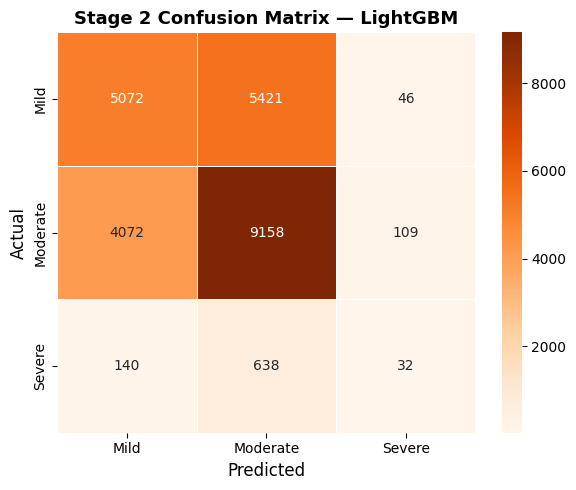

In [ ]:
best2_name  = results2.iloc[0]['Model']
best2_model = trained2[best2_name]

X2_eval = prepare_for_catboost(X2_test, cat_cols) \
          if best2_name == 'CatBoost' else X2_test

y2_pred = best2_model.predict(X2_eval)

print(f"Best Stage 2 model: {best2_name}")
print("=" * 55)
print(classification_report(
    y2_test, y2_pred,
    target_names=['Mild', 'Moderate', 'Severe']
))

# Confusion matrix
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm2, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Mild', 'Moderate', 'Severe'],
    yticklabels=['Mild', 'Moderate', 'Severe'],
    linewidths=0.5
)
plt.title(f'Stage 2 Confusion Matrix — {best2_name}',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('stage2_confusion_matrix.png', dpi=300)
plt.show()

SHAP Analysis — Stage 2 (LightGBM)


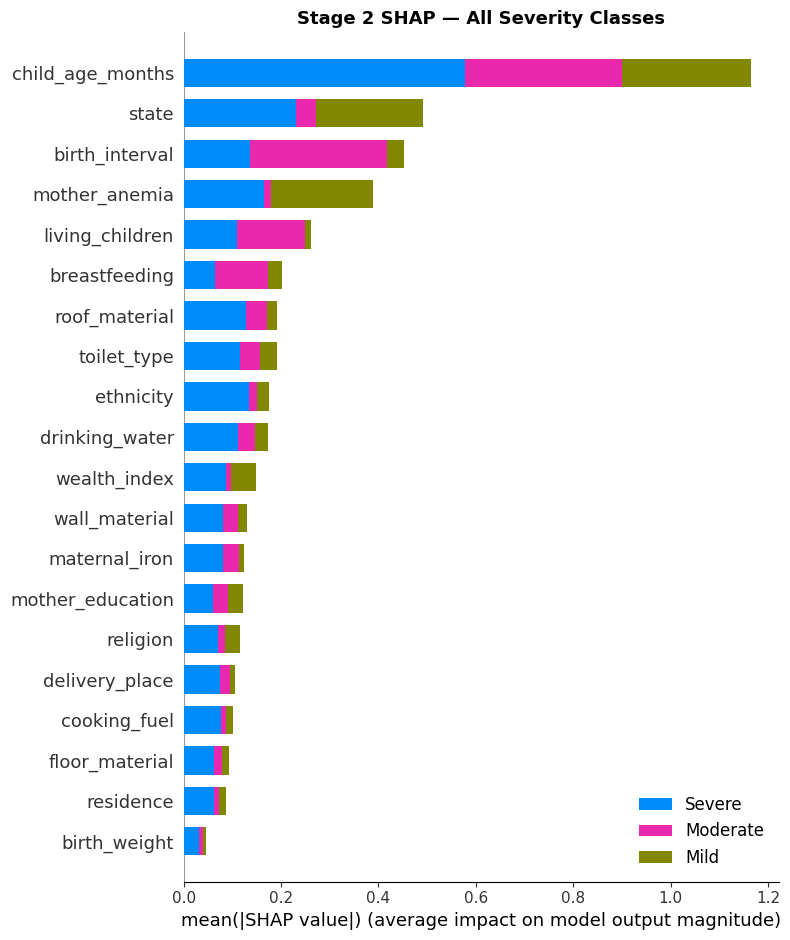

✓ SHAP bar plot saved


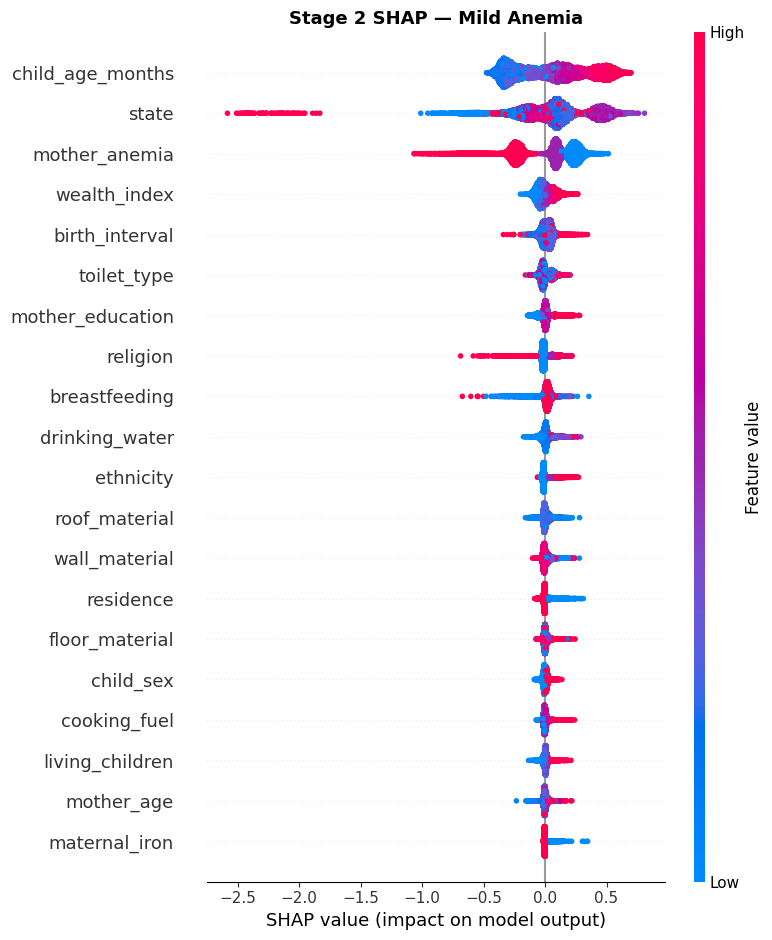

✓ SHAP beeswarm mild saved


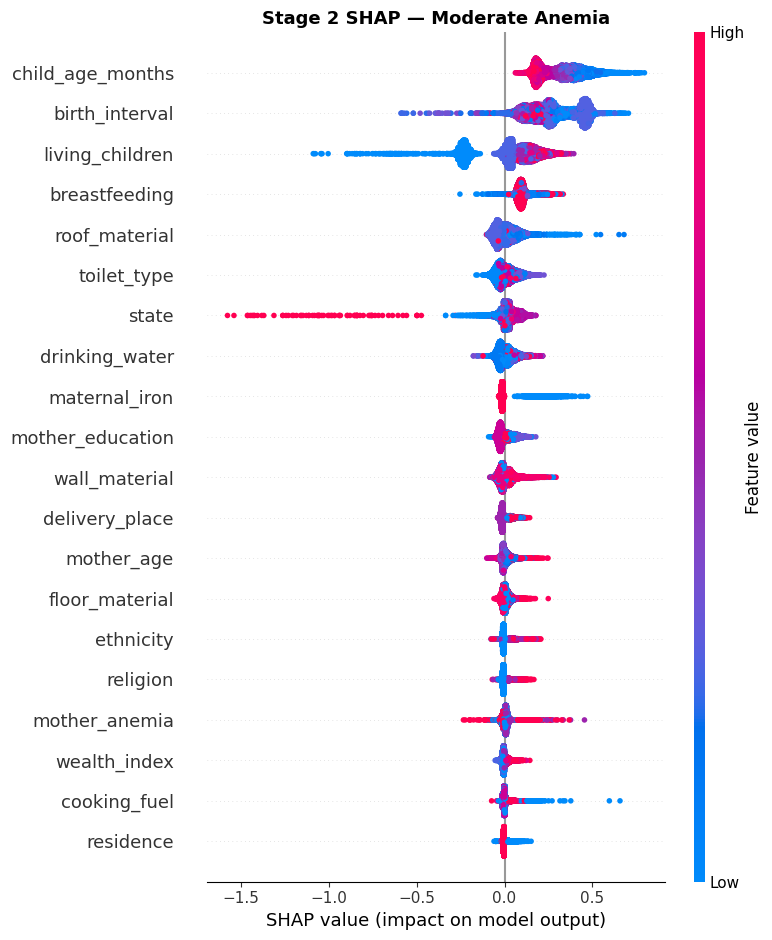

✓ SHAP beeswarm moderate saved


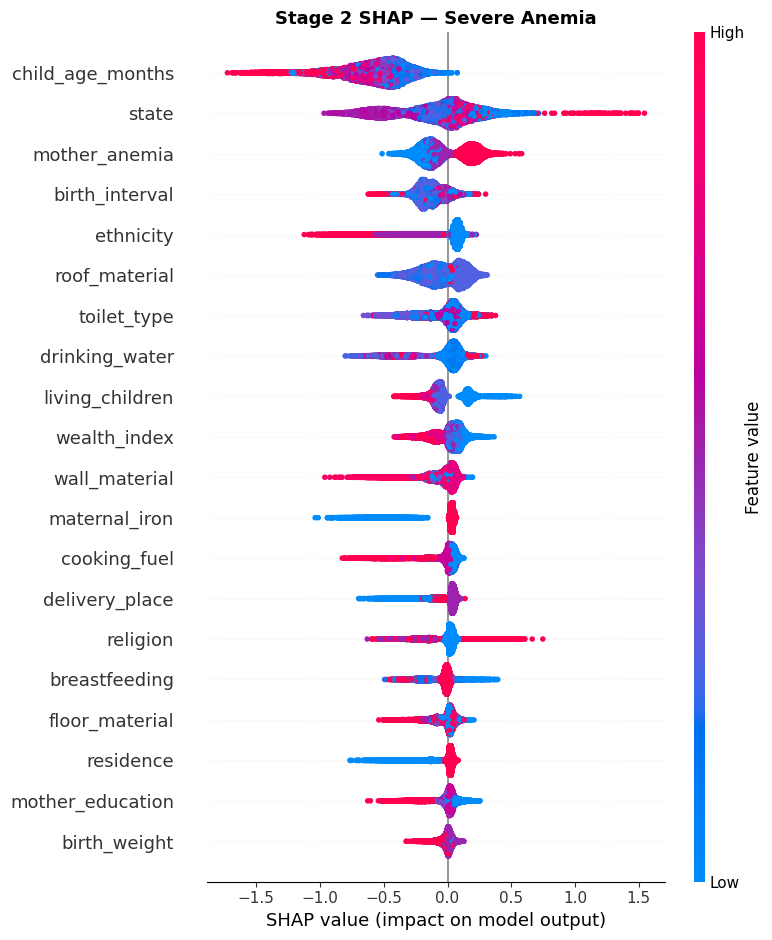

✓ SHAP beeswarm severe saved

Top 10 SHAP features (Stage 2):
 rank          feature  shap_mild  shap_moderate  shap_severe  shap_mean
    1 child_age_months     0.2656         0.3216       0.5777     0.3883
    2            state     0.2207         0.0403       0.2311     0.1640
    3   birth_interval     0.0356         0.2810       0.1360     0.1508
    4    mother_anemia     0.2103         0.0139       0.1651     0.1297
    5  living_children     0.0127         0.1389       0.1097     0.0871
    6    breastfeeding     0.0301         0.1079       0.0646     0.0675
    7    roof_material     0.0201         0.0447       0.1271     0.0640
    8      toilet_type     0.0347         0.0407       0.1164     0.0639
    9        ethnicity     0.0246         0.0168       0.1346     0.0587
   10   drinking_water     0.0262         0.0355       0.1118     0.0578


In [ ]:
print(f"SHAP Analysis — Stage 2 ({best2_name})")
print("=" * 55)

X2_shap = prepare_for_catboost(X2_test, cat_cols) \
          if best2_name == 'CatBoost' else X2_test

explainer2 = shap.TreeExplainer(best2_model)
shap_vals2 = explainer2.shap_values(X2_shap)

# Handle SHAP output format
if isinstance(shap_vals2, list):
    sv2_mild     = shap_vals2[0]
    sv2_moderate = shap_vals2[1]
    sv2_severe   = shap_vals2[2]
else:
    sv2_mild     = shap_vals2[:, :, 0]
    sv2_moderate = shap_vals2[:, :, 1]
    sv2_severe   = shap_vals2[:, :, 2]

# Global bar — all classes
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_vals2, X2_shap,
    plot_type='bar',
    class_names=['Mild', 'Moderate', 'Severe'],
    show=False
)
plt.title('Stage 2 SHAP — All Severity Classes',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage2_shap_bar.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP bar plot saved")

# Beeswarm — mild
plt.figure(figsize=(11, 7))
shap.summary_plot(sv2_mild, X2_shap, show=False)
plt.title('Stage 2 SHAP — Mild Anemia',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage2_shap_beeswarm_mild.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP beeswarm mild saved")

# Beeswarm — moderate
plt.figure(figsize=(11, 7))
shap.summary_plot(sv2_moderate, X2_shap, show=False)
plt.title('Stage 2 SHAP — Moderate Anemia',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage2_shap_beeswarm_moderate.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP beeswarm moderate saved")

# Beeswarm — severe
plt.figure(figsize=(11, 7))
shap.summary_plot(sv2_severe, X2_shap, show=False)
plt.title('Stage 2 SHAP — Severe Anemia',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage2_shap_beeswarm_severe.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP beeswarm severe saved")

# SHAP importance table
shap_importance2 = pd.DataFrame({
    'rank'            : range(1,
                        len(X2_shap.columns)+1),
    'feature'         : X2_shap.columns,
    'shap_mild'       : np.abs(sv2_mild
                        ).mean(axis=0),
    'shap_moderate'   : np.abs(sv2_moderate
                        ).mean(axis=0),
    'shap_severe'     : np.abs(sv2_severe
                        ).mean(axis=0),
}).assign(shap_mean=lambda x: (
    x['shap_mild'] +
    x['shap_moderate'] +
    x['shap_severe']) / 3
).sort_values('shap_mean',
              ascending=False
).reset_index(drop=True)
shap_importance2['rank'] = range(
    1, len(shap_importance2)+1)

print("\nTop 10 SHAP features (Stage 2):")
print(shap_importance2[
    ['rank', 'feature', 'shap_mild',
     'shap_moderate', 'shap_severe',
     'shap_mean']
].head(10).round(4).to_string(index=False))

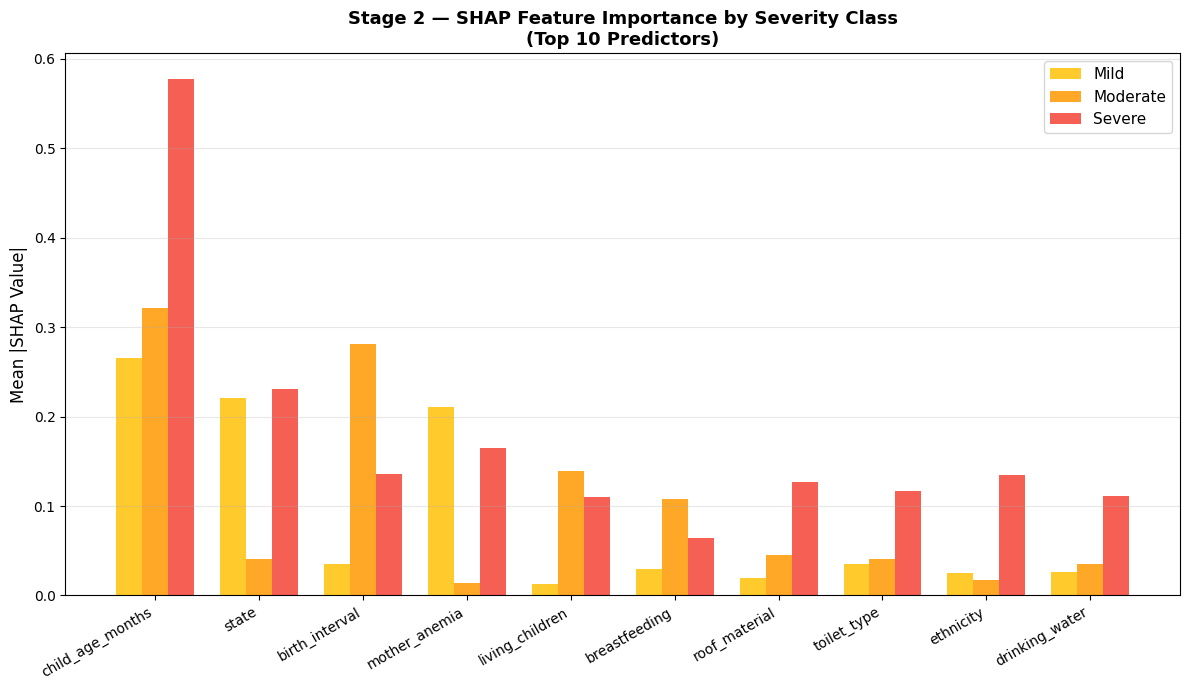

✓ Per-class SHAP comparison saved


In [ ]:
# Side by side SHAP comparison across severity classes
# This becomes Figure X in your paper

top_features = shap_importance2.head(10)['feature'].tolist()
shap_data = shap_importance2[
    shap_importance2['feature'].isin(top_features)
].set_index('feature')[
    ['shap_mild', 'shap_moderate', 'shap_severe']
].loc[top_features]

fig, ax = plt.subplots(figsize=(12, 7))
x  = np.arange(len(top_features))
w  = 0.25
ax.bar(x - w, shap_data['shap_mild'],
       w, label='Mild', color='#FFC107', alpha=0.85)
ax.bar(x,     shap_data['shap_moderate'],
       w, label='Moderate', color='#FF9800', alpha=0.85)
ax.bar(x + w, shap_data['shap_severe'],
       w, label='Severe', color='#F44336', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top_features,
                   rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Mean |SHAP Value|', fontsize=12)
ax.set_title(
    'Stage 2 — SHAP Feature Importance by Severity Class\n'
    '(Top 10 Predictors)',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.show()
print("✓ Per-class SHAP comparison saved")

In [ ]:
import os
import json
import pickle
import shutil
os.makedirs('stage2_results', exist_ok=True)


# Results table
results2.to_csv(
    'stage2_results/stage2_model_comparison.csv',
    index=False)
print("✓ Model comparison saved")

# Classification report
report2 = pd.DataFrame(
    classification_report(
        y2_test, y2_pred,
        target_names=['Mild','Moderate','Severe'],
        output_dict=True)
).transpose()
report2.to_csv(
    'stage2_results/stage2_classification_report.csv')
print("✓ Classification report saved")

# Confusion matrix
pd.DataFrame(
    cm2,
    index=['Actual Mild','Actual Moderate',
           'Actual Severe'],
    columns=['Pred Mild','Pred Moderate',
             'Pred Severe']
).to_csv(
    'stage2_results/stage2_confusion_matrix.csv')
print("✓ Confusion matrix saved")

# SHAP importance
shap_importance2.round(4).to_csv(
    'stage2_results/stage2_shap_importance.csv',
    index=False)
print("✓ SHAP importance saved")

# Metrics JSON
y2_prob_best = best2_model.predict_proba(X2_eval)
stage2_metrics = {
    'best_model'      : best2_name,
    'anemic_records'  : len(df2),
    'mild_count'      : int((y2_test==0).sum()),
    'moderate_count'  : int((y2_test==1).sum()),
    'severe_count'    : int((y2_test==2).sum()),
    'accuracy'        : round(accuracy_score(
                            y2_test, y2_pred), 4),
    'f1_weighted'     : round(f1_score(
                            y2_test, y2_pred,
                            average='weighted',
                            zero_division=0), 4),
    'f1_macro'        : round(f1_score(
                            y2_test, y2_pred,
                            average='macro',
                            zero_division=0), 4),
    'f1_mild'         : round(f1_score(
                            y2_test, y2_pred,
                            labels=[0],
                            average='micro',
                            zero_division=0), 4),
    'f1_moderate'     : round(f1_score(
                            y2_test, y2_pred,
                            labels=[1],
                            average='micro',
                            zero_division=0), 4),
    'f1_severe'       : round(f1_score(
                            y2_test, y2_pred,
                            labels=[2],
                            average='micro',
                            zero_division=0), 4),
    'auc_ovr_weighted': round(roc_auc_score(
                            y2_test, y2_prob_best,
                            multi_class='ovr',
                            average='weighted'), 4),
    'cohen_kappa'     : round(cohen_kappa_score(
                            y2_test, y2_pred), 4),
}
with open('stage2_results/stage2_metrics.json',
          'w') as f:
    json.dump(stage2_metrics, f, indent=2)
print("✓ Metrics JSON saved")

# Best model pickle
with open('stage2_results/best_model_stage2.pkl',
          'wb') as f:
    pickle.dump(best2_model, f)
print("✓ Best model saved")


# Print summary
print("\n" + "=" * 55)
print("STAGE 2 SUMMARY FOR PAPER")
print("=" * 55)
print(f"Best model     : {best2_name}")
print(f"Anemic records : {len(df2):,}")
print(f"Accuracy       : {stage2_metrics['accuracy']}")
print(f"F1 Weighted    : {stage2_metrics['f1_weighted']}")
print(f"F1 Macro       : {stage2_metrics['f1_macro']}")
print(f"AUC (OvR)      : "
      f"{stage2_metrics['auc_ovr_weighted']}")
print(f"Cohen Kappa    : {stage2_metrics['cohen_kappa']}")
print(f"\nPer-class F1:")
print(f"  Mild     : {stage2_metrics['f1_mild']}")
print(f"  Moderate : {stage2_metrics['f1_moderate']}")
print(f"  Severe   : {stage2_metrics['f1_severe']}")
print(f"\nTop 5 SHAP predictors:")
for _, row in shap_importance2.head(5).iterrows():
    print(f"  {int(row['rank'])}. "
          f"{row['feature']:<22} "
          f"mean SHAP={row['shap_mean']:.4f}")

# Zip and download
print("\n── Zipping and downloading ──")
shutil.make_archive(
    'STAGE2_COMPLETE', 'zip', 'stage2_results')
file_size = os.path.getsize(
    'STAGE2_COMPLETE.zip') / 1e6
print(f"Zip: STAGE2_COMPLETE.zip "
      f"({file_size:.1f} MB)")
files.download('STAGE2_COMPLETE.zip')
print("Download started.")

✓ Model comparison saved
✓ Classification report saved
✓ Confusion matrix saved
✓ SHAP importance saved
✓ Metrics JSON saved
✓ Best model saved

STAGE 2 SUMMARY FOR PAPER
Best model     : LightGBM
Anemic records : 123,436
Accuracy       : 0.5777
F1 Weighted    : 0.5671
F1 Macro       : 0.4058
AUC (OvR)      : 0.6133
Cohen Kappa    : 0.1657

Per-class F1:
  Mild     : 0.5117
  Moderate : 0.6414
  Severe   : 0.0642

Top 5 SHAP predictors:
  1. child_age_months       mean SHAP=0.3883
  2. state                  mean SHAP=0.1640
  3. birth_interval         mean SHAP=0.1508
  4. mother_anemia          mean SHAP=0.1297
  5. living_children        mean SHAP=0.0871

── Zipping and downloading ──
Zip: STAGE2_COMPLETE.zip (1.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


In [ ]:
# ── Step 2: Add survey weights to df2 ────────────
df2['survey_weight'] = df_raw.loc[
    df2.index, 'v005'] / 1e6

print("Survey weight added to df2.")
print(f"Weight range: "
      f"{df2['survey_weight'].min():.4f} — "
      f"{df2['survey_weight'].max():.4f}")

Survey weight added to df2.
Weight range: 0.0035 — 37.5859


In [ ]:
# Quick sanity check before Step 3
print("df2 shape:", df2.shape)
print("survey_weight nulls:",
      df2['survey_weight'].isnull().sum())
print("severity distribution:")
print(df2['severity'].value_counts().sort_index()
        .rename({0:'Mild',1:'Moderate',2:'Severe'}))

df2 shape: (123436, 27)
survey_weight nulls: 0
severity distribution:
severity
Mild        52694
Moderate    66692
Severe       4050
Name: count, dtype: int64


In [ ]:
# ── Step 3: Weighted severity by state ───────────
state_severity_w = []

for state_code in sorted(df2['state'].unique()):
    sd = df2[df2['state'] == state_code].copy()
    if len(sd) < 100:
        continue

    w_total = sd['survey_weight'].sum()
    if w_total == 0:
        continue

    mild_w = sd.loc[
        sd['severity']==0,
        'survey_weight'].sum()
    mod_w  = sd.loc[
        sd['severity']==1,
        'survey_weight'].sum()
    sev_w  = sd.loc[
        sd['severity']==2,
        'survey_weight'].sum()

    state_severity_w.append({
        'state'       : state_code,
        'n_anemic'    : len(sd),
        'mild_pct'    : round(mild_w/w_total*100, 1),
        'moderate_pct': round(mod_w/w_total*100, 1),
        'severe_pct'  : round(sev_w/w_total*100, 1),
    })

state_sev_w = pd.DataFrame(state_severity_w)
state_sev_w['state_name'] = \
    state_sev_w['state'].astype(int).map(
    state_name_map)

# Filter reliable states
state_sev_reliable = state_sev_w[
    state_sev_w['n_anemic'] >= 500].copy()

print(f"Total states analyzed: {len(state_sev_w)}")
print(f"Reliable states (n≥500): "
      f"{len(state_sev_reliable)}")

print("\nWeighted severity by state "
      "(sorted by severe %):")
print(state_sev_reliable[[
    'state_name', 'n_anemic',
    'mild_pct', 'moderate_pct', 'severe_pct'
]].sort_values(
    'severe_pct',
    ascending=False).to_string(index=False))

print(f"\nNational weighted averages:")
print(f"  Mild:     "
      f"{state_sev_reliable['mild_pct'].mean():.1f}%")
print(f"  Moderate: "
      f"{state_sev_reliable['moderate_pct'].mean():.1f}%")
print(f"  Severe:   "
      f"{state_sev_reliable['severe_pct'].mean():.1f}%")

Total states analyzed: 34
Reliable states (n≥500): 28

Weighted severity by state (sorted by severe %):
       state_name  n_anemic  mild_pct  moderate_pct  severe_pct
           Punjab      3000      35.7          57.2         7.1
     NCT of Delhi      1493      38.2          54.8         7.0
          Haryana      3714      37.2          57.8         5.1
        Telangana      3883      35.6          59.3         5.1
  Jammu & Kashmir      3671      31.8          63.2         5.0
      Uttarakhand      1636      41.5          53.6         4.9
   Madhya Pradesh      8987      37.8          57.8         4.4
        Karnataka      4421      41.3          54.4         4.3
          Gujarat      6490      34.3          61.7         4.0
 Himachal Pradesh      1308      47.4          48.8         3.9
   Andhra Pradesh      1387      41.4          55.0         3.7
Arunachal Pradesh      2556      50.7          45.8         3.6
      Maharashtra      5558      41.9          54.5         3.5


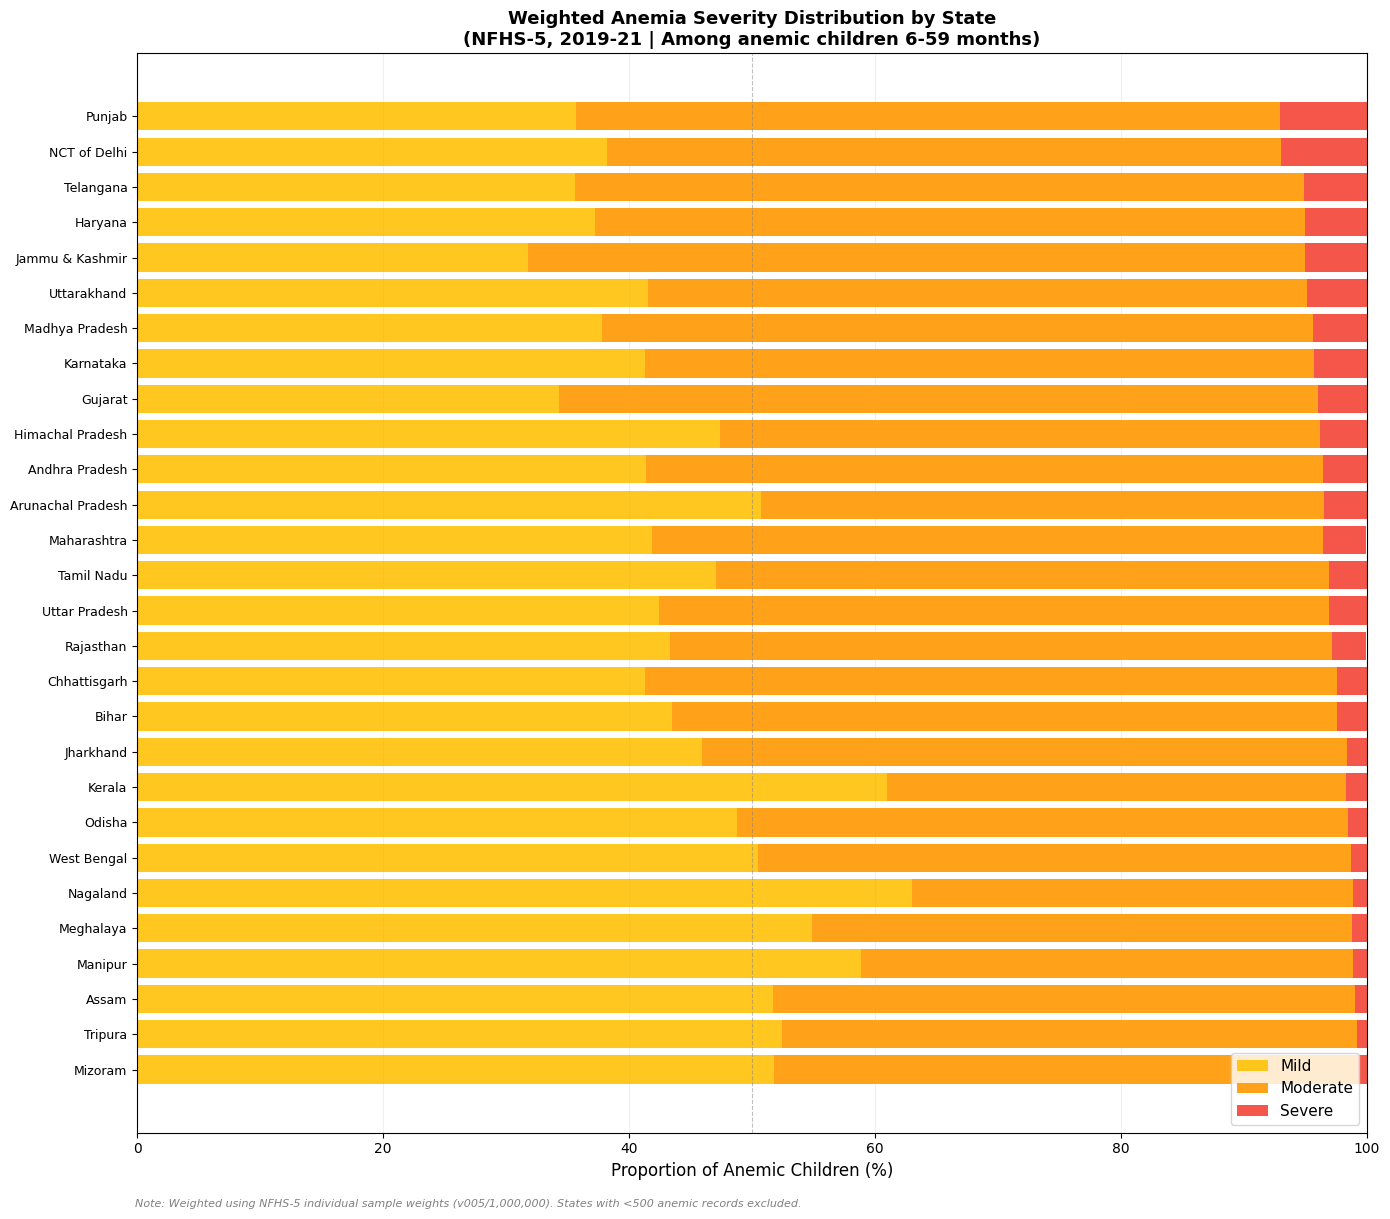

✓ Stacked bar saved


In [ ]:
# ── Step 4: Stacked bar chart ─────────────────────
state_plot = state_sev_reliable.sort_values(
    'severe_pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 12))
y_pos = range(len(state_plot))

ax.barh(y_pos, state_plot['mild_pct'],
        color='#FFC107', label='Mild', alpha=0.9)
ax.barh(y_pos, state_plot['moderate_pct'],
        left=state_plot['mild_pct'],
        color='#FF9800', label='Moderate', alpha=0.9)
ax.barh(y_pos, state_plot['severe_pct'],
        left=state_plot['mild_pct'] +
             state_plot['moderate_pct'],
        color='#F44336', label='Severe', alpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels(state_plot['state_name'],
                   fontsize=9)
ax.set_xlabel(
    'Proportion of Anemic Children (%)',
    fontsize=12)
ax.set_title(
    'Weighted Anemia Severity Distribution '
    'by State\n'
    '(NFHS-5, 2019-21 | '
    'Among anemic children 6-59 months)',
    fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(0, 100)
ax.axvline(x=50, color='gray',
           linestyle='--', lw=0.8, alpha=0.5)
ax.grid(True, axis='x', alpha=0.2)
fig.text(
    0.1, -0.01,
    'Note: Weighted using NFHS-5 individual '
    'sample weights (v005/1,000,000). '
    'States with <500 anemic records excluded.',
    fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.savefig(
    'stage2_results/'
    'state_severity_stacked_bar_weighted.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Stacked bar saved")

In [ ]:
# ── Step 5: Load shapefile ────────────────────────
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import urllib.request
import zipfile

if not os.path.exists(
        '/content/ne_shapefile/'
        'ne_10m_admin_1_states_provinces.shp'):
    print("Downloading shapefile...")
    urllib.request.urlretrieve(
        "https://naciscdn.org/naturalearth/10m/"
        "cultural/"
        "ne_10m_admin_1_states_provinces.zip",
        '/content/ne_shapefile.zip'
    )
    with zipfile.ZipFile(
            '/content/ne_shapefile.zip', 'r') as z:
        z.extractall('/content/ne_shapefile')
    print("Downloaded.")
else:
    print("Shapefile already exists.")

world_states = gpd.read_file(
    '/content/ne_shapefile/'
    'ne_10m_admin_1_states_provinces.shp'
)
india = world_states[
    world_states['admin'] == 'India'].copy()

name_match = {
    'Jammu and Kashmir'   : 'Jammu & Kashmir',
    'Himachal Pradesh'    : 'Himachal Pradesh',
    'Punjab'              : 'Punjab',
    'Chandigarh'          : 'Chandigarh',
    'Uttarakhand'         : 'Uttarakhand',
    'Haryana'             : 'Haryana',
    'NCT of Delhi'        : 'NCT of Delhi',
    'Delhi'               : 'NCT of Delhi',
    'Rajasthan'           : 'Rajasthan',
    'Uttar Pradesh'       : 'Uttar Pradesh',
    'Bihar'               : 'Bihar',
    'Sikkim'              : 'Sikkim',
    'Arunachal Pradesh'   : 'Arunachal Pradesh',
    'Nagaland'            : 'Nagaland',
    'Manipur'             : 'Manipur',
    'Mizoram'             : 'Mizoram',
    'Tripura'             : 'Tripura',
    'Meghalaya'           : 'Meghalaya',
    'Assam'               : 'Assam',
    'West Bengal'         : 'West Bengal',
    'Jharkhand'           : 'Jharkhand',
    'Odisha'              : 'Odisha',
    'Chhattisgarh'        : 'Chhattisgarh',
    'Madhya Pradesh'      : 'Madhya Pradesh',
    'Gujarat'             : 'Gujarat',
    'Maharashtra'         : 'Maharashtra',
    'Andhra Pradesh'      : 'Andhra Pradesh',
    'Karnataka'           : 'Karnataka',
    'Goa'                 : 'Goa',
    'Kerala'              : 'Kerala',
    'Tamil Nadu'          : 'Tamil Nadu',
    'Telangana'           : 'Telangana',
    'Andaman and Nicobar' : 'Andaman & Nicobar',
    'Andaman and Nicobar Islands':
        'Andaman & Nicobar',
    'Lakshadweep'         : 'Lakshadweep',
    'Puducherry'          : 'Puducherry',
    'Ladakh'              : 'Ladakh',
    'Dadra and Nagar Haveli and Daman and Diu':
        'Dadra & NH and D&D',
}

india['state_name'] = india['name'].map(name_match)
print(f"India states loaded: {len(india)}")

Shapefile already exists.
India states loaded: 36


In [ ]:
# ── Step 6: Merge ─────────────────────────────────
india_sev = india.merge(
    state_sev_w[[
        'state_name', 'severe_pct',
        'moderate_pct', 'mild_pct',
        'n_anemic']],
    on='state_name', how='left'
)

matched   = india_sev['severe_pct'].notna().sum()
unmatched = india_sev['severe_pct'].isna().sum()
print(f"Matched: {matched} | Unmatched: {unmatched}")

if unmatched > 0:
    print("Unmatched:")
    print(india_sev[
        india_sev['severe_pct'].isna()][
        ['name','state_name']])

Matched: 34 | Unmatched: 2
Unmatched:
           name   state_name
27  Lakshadweep  Lakshadweep
31   Chandigarh   Chandigarh


In [ ]:
# Quick confirmation before plotting
print("States in shapefile:", len(india_sev))
print("States with data:",
      india_sev['severe_pct'].notna().sum())
print("States grey (no data):",
      india_sev['severe_pct'].isna().sum())
print("\nGrey states:")
print(india_sev[india_sev['severe_pct'].isna()][
    ['name']].values.flatten().tolist())

States in shapefile: 36
States with data: 34
States grey (no data): 2

Grey states:
['Lakshadweep', 'Chandigarh']


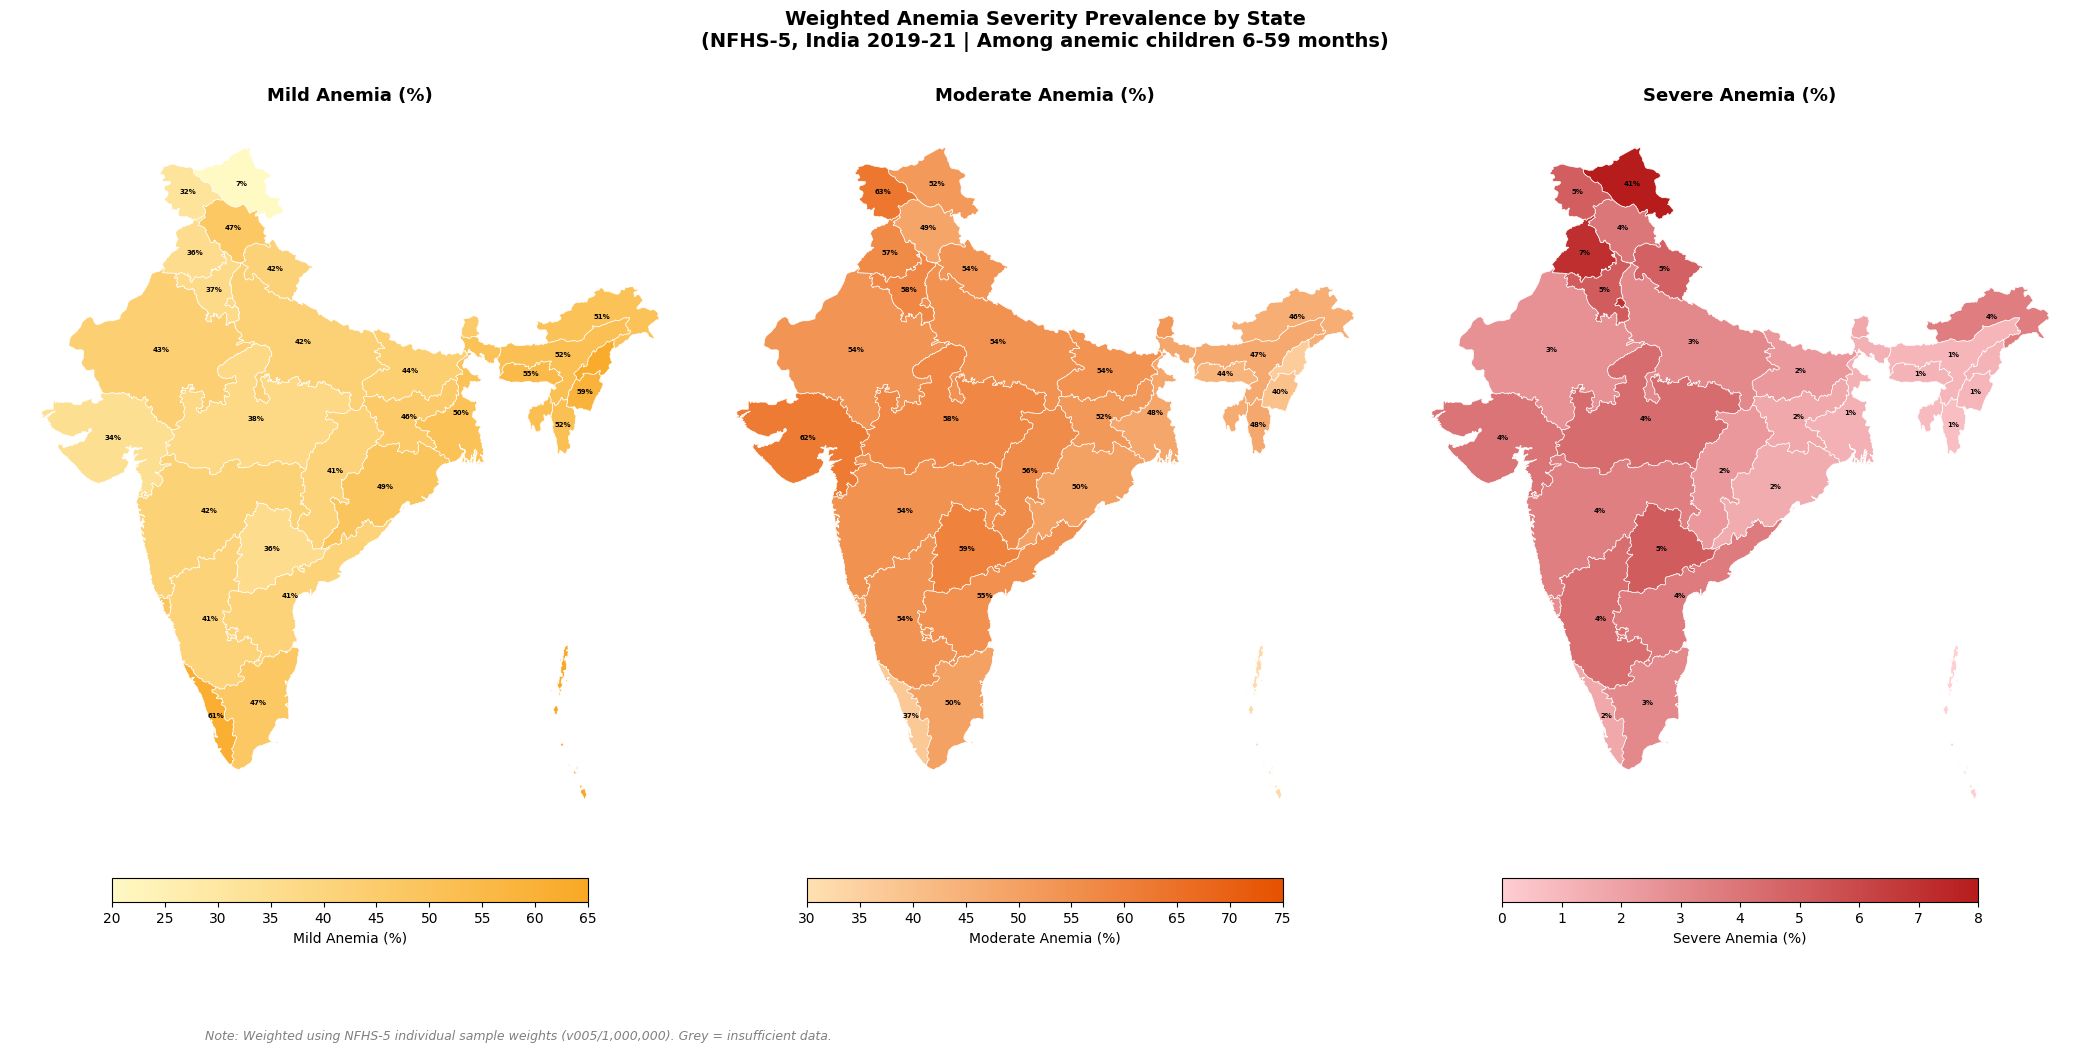

✓ Three severity maps saved


In [ ]:
# ── Step 7: Three severity maps ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 10))

severity_info = [
    ('mild_pct',     'Mild Anemia (%)',
     ['#fff9c4','#f9a825'], 20, 65),
    ('moderate_pct', 'Moderate Anemia (%)',
     ['#ffe0b2','#e65100'], 30, 75),
    ('severe_pct',   'Severe Anemia (%)',
     ['#ffcdd2','#b71c1c'],  0,  8),
]

for ax, (col, title, clrs,
         vmin, vmax) in zip(axes, severity_info):
    cmap = LinearSegmentedColormap.from_list(
        title, clrs)

    india_sev.plot(
        column=col,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='white',
        legend=True,
        legend_kwds={
            'label'      : title,
            'orientation': 'horizontal',
            'shrink'     : 0.7,
            'pad'        : 0.05,
        },
        missing_kwds={
            'color'    : 'lightgrey',
            'edgecolor': 'white',
        },
        vmin=vmin, vmax=vmax,
        ax=ax
    )

    for _, row in india_sev.iterrows():
        if pd.notna(row[col]) and \
           row['geometry'].area > 1.5:
            centroid = row['geometry'].centroid
            ax.annotate(
                f"{row[col]:.0f}%",
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=5,
                color='black',
                fontweight='bold'
            )
    ax.set_title(title, fontsize=13,
                 fontweight='bold', pad=10)
    ax.set_axis_off()

plt.suptitle(
    'Weighted Anemia Severity Prevalence '
    'by State\n'
    '(NFHS-5, India 2019-21 | '
    'Among anemic children 6-59 months)',
    fontsize=14, fontweight='bold', y=1.02)
fig.text(
    0.1, -0.01,
    'Note: Weighted using NFHS-5 individual '
    'sample weights (v005/1,000,000). '
    'Grey = insufficient data.',
    fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.savefig(
    'stage2_results/'
    'state_severity_maps_weighted.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Three severity maps saved")

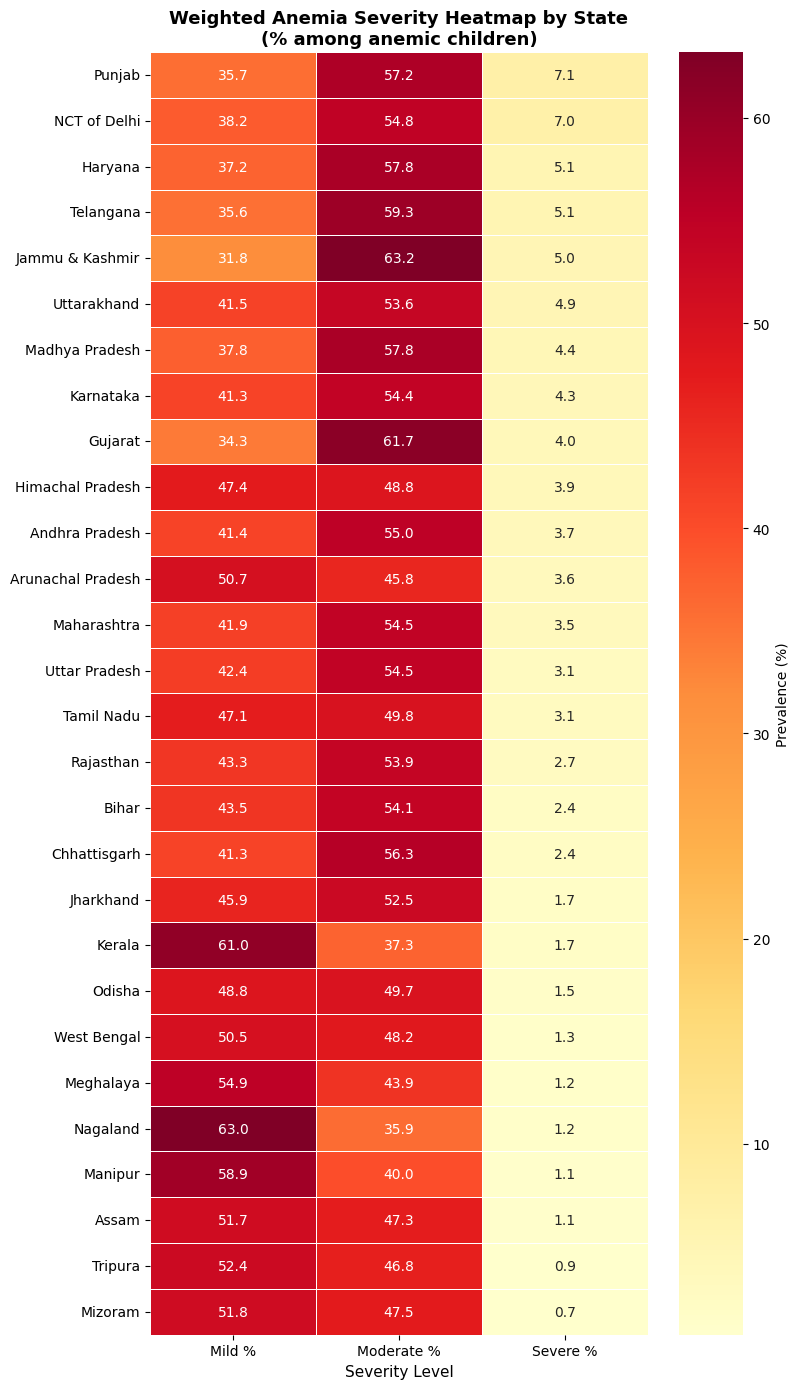

✓ Heatmap saved


In [ ]:
# ── Step 8: Heatmap ───────────────────────────────
pivot_data = state_sev_reliable.set_index(
    'state_name')[
    ['mild_pct','moderate_pct','severe_pct']
].sort_values('severe_pct', ascending=False)
pivot_data.columns = ['Mild %',
                      'Moderate %',
                      'Severe %']

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    pivot_data,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label':'Prevalence (%)'}
)
ax.set_title(
    'Weighted Anemia Severity Heatmap '
    'by State\n(% among anemic children)',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Severity Level', fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(
    'stage2_results/'
    'state_severity_heatmap_weighted.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Heatmap saved")

In [ ]:
# ── Step 9: Summary table ─────────────────────────
print("Top 5 states — SEVERE anemia (weighted):")
print(state_sev_reliable.nlargest(
    5, 'severe_pct')[
    ['state_name','severe_pct',
     'moderate_pct','mild_pct',
     'n_anemic']].to_string(index=False))

print("\nTop 5 states — MILD anemia (weighted):")
print(state_sev_reliable.nlargest(
    5, 'mild_pct')[
    ['state_name','mild_pct',
     'moderate_pct','severe_pct',
     'n_anemic']].to_string(index=False))

print(f"\nNational weighted averages:")
print(f"  Mild:     "
      f"{state_sev_reliable['mild_pct'].mean():.1f}%")
print(f"  Moderate: "
      f"{state_sev_reliable['moderate_pct'].mean():.1f}%")
print(f"  Severe:   "
      f"{state_sev_reliable['severe_pct'].mean():.1f}%")

state_sev_reliable.sort_values(
    'severe_pct', ascending=False
).to_csv(
    'stage2_results/'
    'state_severity_weighted_table.csv',
    index=False)
print("\n✓ Table saved")

Top 5 states — SEVERE anemia (weighted):
     state_name  severe_pct  moderate_pct  mild_pct  n_anemic
         Punjab         7.1          57.2      35.7      3000
   NCT of Delhi         7.0          54.8      38.2      1493
        Haryana         5.1          57.8      37.2      3714
      Telangana         5.1          59.3      35.6      3883
Jammu & Kashmir         5.0          63.2      31.8      3671

Top 5 states — MILD anemia (weighted):
state_name  mild_pct  moderate_pct  severe_pct  n_anemic
  Nagaland      63.0          35.9         1.2      1135
    Kerala      61.0          37.3         1.7       859
   Manipur      58.9          40.0         1.1      1162
 Meghalaya      54.9          43.9         1.2      2571
   Tripura      52.4          46.8         0.9      1151

National weighted averages:
  Mild:     45.4%
  Moderate: 51.5%
  Severe:   3.1%

✓ Table saved


In [ ]:
import os
from google.colab import files

# ── Prepare the table ─────────────────────────────
table4 = state_sev_reliable[[
    'state_name', 'n_anemic',
    'mild_pct', 'moderate_pct', 'severe_pct'
]].sort_values(
    'severe_pct', ascending=False
).reset_index(drop=True)

# Rename columns for publication
table4.columns = [
    'State/UT',
    'N (Anemic Children)',
    'Mild (%)',
    'Moderate (%)',
    'Severe (%)'
]

# Add rank column
table4.insert(0, 'Rank',
              range(1, len(table4)+1))

# Add national average row at bottom
national_row = pd.DataFrame([{
    'Rank'                 : '—',
    'State/UT'             : 'National Average',
    'N (Anemic Children)'  : state_sev_reliable[
                                 'n_anemic'].sum(),
    'Mild (%)'             : round(
        state_sev_reliable['mild_pct'].mean(), 1),
    'Moderate (%)'         : round(
        state_sev_reliable['moderate_pct'].mean(), 1),
    'Severe (%)'           : round(
        state_sev_reliable['severe_pct'].mean(), 1),
}])

table4 = pd.concat(
    [table4, national_row],
    ignore_index=True)

# Print full table
print("Table 4 — Weighted Anemia Severity "
      "Distribution by State")
print("(NFHS-5, India 2019-21 | "
      "Among anemic children 6-59 months)")
print("=" * 75)
print(table4.to_string(index=False))
print("\nNote: Weighted using NFHS-5 individual "
      "sample weights (v005/1,000,000).")
print("States/UTs with <500 anemic records "
      "excluded.")

# ── Save as CSV ───────────────────────────────────
table4.to_csv(
    'stage2_results/table4_state_severity.csv',
    index=False)
print("\n✓ CSV saved")

# ── Save as formatted Excel ───────────────────────
try:
    import openpyxl
    from openpyxl.styles import (
        Font, PatternFill, Alignment,
        Border, Side)
    from openpyxl.utils import get_column_letter

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Table 4"

    # Title row
    ws.merge_cells('A1:F1')
    title_cell = ws['A1']
    title_cell.value = (
        "Table 4 — Weighted Anemia Severity "
        "Distribution by State/UT")
    title_cell.font = Font(
        bold=True, size=12)
    title_cell.alignment = Alignment(
        horizontal='center')

    # Subtitle row
    ws.merge_cells('A2:F2')
    sub_cell = ws['A2']
    sub_cell.value = (
        "NFHS-5, India 2019-21 | "
        "Among anemic children aged 6-59 months | "
        "Weighted estimates")
    sub_cell.font = Font(
        italic=True, size=10)
    sub_cell.alignment = Alignment(
        horizontal='center')

    # Header row
    header_fill = PatternFill(
        start_color='1565C0',
        end_color='1565C0',
        fill_type='solid')
    header_font = Font(
        bold=True, color='FFFFFF', size=10)

    headers = list(table4.columns)
    for col, header in enumerate(
            headers, start=1):
        cell = ws.cell(
            row=3, column=col, value=header)
        cell.fill  = header_fill
        cell.font  = header_font
        cell.alignment = Alignment(
            horizontal='center',
            vertical='center',
            wrap_text=True)

    # Data rows
    thin = Side(style='thin',
                color='CCCCCC')
    border = Border(
        left=thin, right=thin,
        top=thin, bottom=thin)

    for row_idx, row in table4.iterrows():
        excel_row = row_idx + 4

        # Alternate row colors
        if row['State/UT'] == 'National Average':
            fill_color = 'E3F2FD'  # light blue
            font_bold  = True
        elif row_idx % 2 == 0:
            fill_color = 'F5F5F5'  # light grey
            font_bold  = False
        else:
            fill_color = 'FFFFFF'  # white
            font_bold  = False

        row_fill = PatternFill(
            start_color=fill_color,
            end_color=fill_color,
            fill_type='solid')

        for col_idx, value in enumerate(
                row.values, start=1):
            cell = ws.cell(
                row=excel_row,
                column=col_idx,
                value=value)
            cell.fill   = row_fill
            cell.border = border
            cell.font   = Font(
                bold=font_bold, size=10)
            cell.alignment = Alignment(
                horizontal='center'
                if col_idx != 2
                else 'left',
                vertical='center')

            # Color code severe % column
            if col_idx == 6 and \
               isinstance(value, float):
                if value >= 5.0:
                    cell.font = Font(
                        bold=True,
                        color='C62828',
                        size=10)
                elif value <= 1.5:
                    cell.font = Font(
                        bold=True,
                        color='2E7D32',
                        size=10)

    # Column widths
    col_widths = [8, 30, 18, 12, 14, 12]
    for i, width in enumerate(
            col_widths, start=1):
        ws.column_dimensions[
            get_column_letter(i)].width = width

    # Row height for header
    ws.row_dimensions[3].height = 35

    # Footnote
    note_row = len(table4) + 5
    ws.merge_cells(
        f'A{note_row}:F{note_row}')
    note_cell = ws[f'A{note_row}']
    note_cell.value = (
        "Note: Weighted using NFHS-5 individual "
        "sample weights (v005/1,000,000) as per "
        "DHS standard protocol. States/UTs with "
        "<500 anemic records excluded due to "
        "insufficient sample size. "
        "Severe % highlighted in red (≥5.0%) "
        "and green (≤1.5%).")
    note_cell.font = Font(
        italic=True, size=9, color='555555')
    note_cell.alignment = Alignment(
        wrap_text=True)
    ws.row_dimensions[note_row].height = 45

    wb.save('stage2_results/table4_state_severity.xlsx')
    print("✓ Excel table saved")

except ImportError:
    print("openpyxl not available — "
          "CSV saved only")

# ── Download ──────────────────────────────────────
files.download(
    'stage2_results/table4_state_severity.csv')
files.download(
    'stage2_results/table4_state_severity.xlsx')
print("✓ Downloads started")

Table 4 — Weighted Anemia Severity Distribution by State
(NFHS-5, India 2019-21 | Among anemic children 6-59 months)
Rank          State/UT  N (Anemic Children)  Mild (%)  Moderate (%)  Severe (%)
   1            Punjab                 3000      35.7          57.2         7.1
   2      NCT of Delhi                 1493      38.2          54.8         7.0
   3           Haryana                 3714      37.2          57.8         5.1
   4         Telangana                 3883      35.6          59.3         5.1
   5   Jammu & Kashmir                 3671      31.8          63.2         5.0
   6       Uttarakhand                 1636      41.5          53.6         4.9
   7    Madhya Pradesh                 8987      37.8          57.8         4.4
   8         Karnataka                 4421      41.3          54.4         4.3
   9           Gujarat                 6490      34.3          61.7         4.0
  10  Himachal Pradesh                 1308      47.4          48.8         3.9
  1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads started


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs(
    '/content/stage1_results/figures',
    exist_ok=True)

# ── Weighted counts ───────────────────────────────
labels4  = ['Not Anemic', 'Mild',
            'Moderate', 'Severe']
colors4  = ['#4CAF50', '#FFC107',
            '#FF9800', '#F44336']

w_counts = []
for level in [0, 1, 2, 3]:
    mask    = df['anemia_level'] == level
    w_count = df.loc[
        mask, 'survey_weight'].sum()
    w_counts.append(w_count)

total_w = sum(w_counts)

print("Weighted class distribution:")
print(f"{'Class':<15} {'Weighted N':>12} "
      f"{'%':>8}")
print("-" * 37)
for label, cnt in zip(labels4, w_counts):
    print(f"{label:<15} {cnt:>12,.0f} "
          f"{cnt/total_w*100:>7.1f}%")
print(f"\n{'Total':<15} {total_w:>12,.0f} "
      f"{'100.0%':>8}")

# Compare with unweighted
print("\nComparison — Unweighted vs Weighted:")
print(f"{'Class':<15} {'Unweighted%':>13} "
      f"{'Weighted%':>11}")
print("-" * 42)
for level, label in enumerate(labels4):
    uw_pct = (df['anemia_level']==level
              ).mean() * 100
    w_pct  = w_counts[level] / total_w * 100
    diff   = w_pct - uw_pct
    print(f"{label:<15} {uw_pct:>12.1f}% "
          f"{w_pct:>10.1f}%  "
          f"({diff:+.1f}%)")

Weighted class distribution:
Class             Weighted N        %
-------------------------------------
Not Anemic            57,299    32.0%
Mild                  52,367    29.2%
Moderate              65,765    36.7%
Severe                 3,796     2.1%

Total                179,227   100.0%

Comparison — Unweighted vs Weighted:
Class             Unweighted%   Weighted%
------------------------------------------
Not Anemic              32.8%       32.0%  (-0.9%)
Mild                    28.7%       29.2%  (+0.6%)
Moderate                36.3%       36.7%  (+0.4%)
Severe                   2.2%        2.1%  (-0.1%)


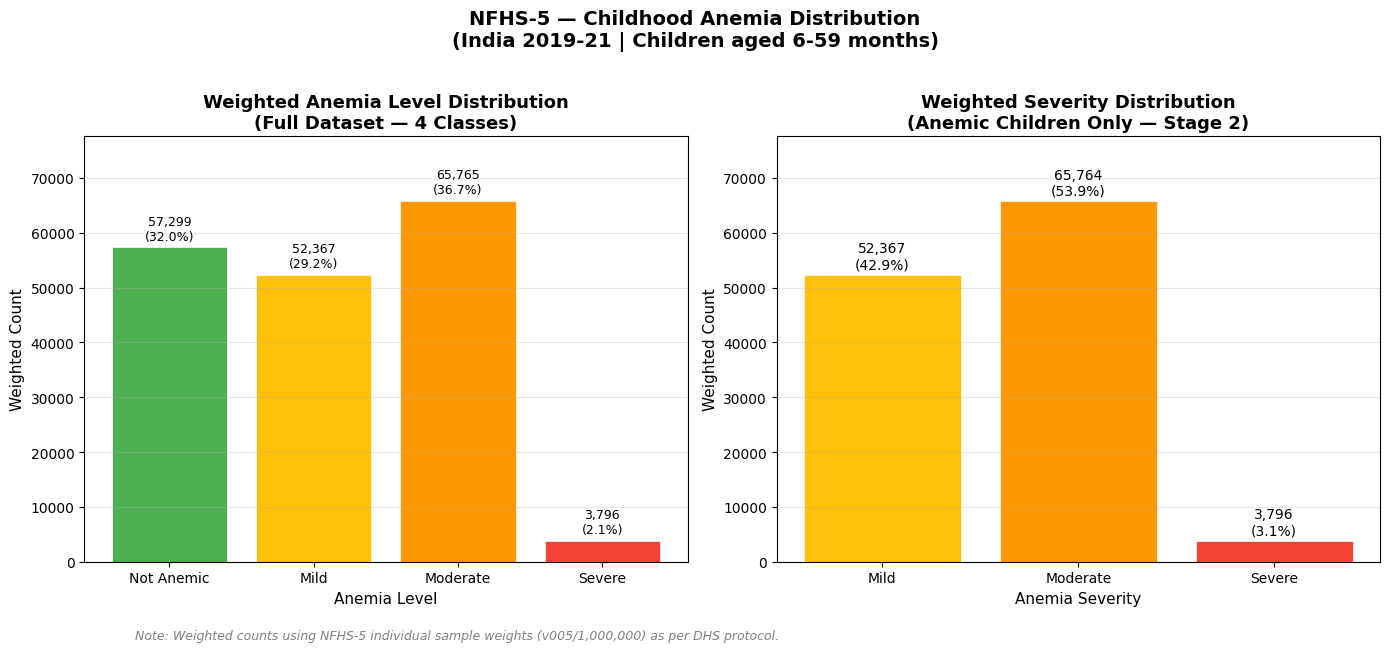

✓ Weighted distribution figure saved
✓ Copied to stage2_results


In [ ]:
# ── Figure — weighted distribution ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — 4-class full dataset (weighted)
bars1 = axes[0].bar(
    labels4, w_counts,
    color=colors4, edgecolor='white',
    linewidth=0.5)
axes[0].set_title(
    'Weighted Anemia Level Distribution\n'
    '(Full Dataset — 4 Classes)',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel(
    'Weighted Count', fontsize=11)
axes[0].set_xlabel(
    'Anemia Level', fontsize=11)
for bar, cnt in zip(bars1, w_counts):
    pct = cnt / total_w * 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_w*0.005,
        f'{cnt:,.0f}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_ylim(0, max(w_counts) * 1.18)

# Right — 3-class anemic subset (weighted)
df2['survey_weight'] = df_raw.loc[
    df2.index, 'v005'] / 1e6

labels3  = ['Mild', 'Moderate', 'Severe']
colors3  = ['#FFC107', '#FF9800', '#F44336']
w_counts3 = []
for level in [0, 1, 2]:
    mask     = df2['severity'] == level
    w_count3 = df2.loc[
        mask, 'survey_weight'].sum()
    w_counts3.append(w_count3)

total_w3 = sum(w_counts3)

bars2 = axes[1].bar(
    labels3, w_counts3,
    color=colors3, edgecolor='white',
    linewidth=0.5)
axes[1].set_title(
    'Weighted Severity Distribution\n'
    '(Anemic Children Only — Stage 2)',
    fontsize=13, fontweight='bold')
axes[1].set_ylabel(
    'Weighted Count', fontsize=11)
axes[1].set_xlabel(
    'Anemia Severity', fontsize=11)
for bar, cnt in zip(bars2, w_counts3):
    pct = cnt / total_w3 * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total_w3*0.005,
        f'{cnt:,.0f}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_ylim(0, max(w_counts3) * 1.18)

plt.suptitle(
    'NFHS-5 — Childhood Anemia Distribution\n'
    '(India 2019-21 | '
    'Children aged 6-59 months)',
    fontsize=14, fontweight='bold', y=1.02)

fig.text(
    0.1, -0.03,
    'Note: Weighted counts using NFHS-5 '
    'individual sample weights '
    '(v005/1,000,000) as per DHS protocol.',
    fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/'
    'B4_class_distribution_weighted.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Weighted distribution figure saved")

# Also save to stage2_results
import shutil
shutil.copy(
    '/content/stage1_results/figures/'
    'B4_class_distribution_weighted.png',
    'stage2_results/'
    'B4_class_distribution_weighted.png')
print("✓ Copied to stage2_results")

In [ ]:
# Calculate weighted distribution
# to replace these unweighted figures

print("Stage 1 — Unweighted vs Weighted")
print("=" * 60)
print(f"{'Metric':<25} {'Unweighted':>12} "
      f"{'Weighted':>12} {'Difference':>12}")
print("-" * 60)

# From your saved JSON (unweighted)
uw_figures = {
    'Not Anemic %' : 32.85,
    'Mild %'       : 28.67,
    'Moderate %'   : 36.28,
    'Severe %'     : 2.20,
    'Anemia prev %': 67.15,
}

# Calculate weighted equivalents
w_total = df['survey_weight'].sum()

w_not_anemic = df.loc[
    df['anemia_level']==0,
    'survey_weight'].sum() / w_total * 100

w_mild = df.loc[
    df['anemia_level']==1,
    'survey_weight'].sum() / w_total * 100

w_moderate = df.loc[
    df['anemia_level']==2,
    'survey_weight'].sum() / w_total * 100

w_severe = df.loc[
    df['anemia_level']==3,
    'survey_weight'].sum() / w_total * 100

w_prevalence = df.loc[
    df['anemia_level']>0,
    'survey_weight'].sum() / w_total * 100

weighted_figures = {
    'Not Anemic %' : round(w_not_anemic, 2),
    'Mild %'       : round(w_mild, 2),
    'Moderate %'   : round(w_moderate, 2),
    'Severe %'     : round(w_severe, 2),
    'Anemia prev %': round(w_prevalence, 2),
}

for metric in uw_figures:
    uw  = uw_figures[metric]
    w   = weighted_figures[metric]
    diff = w - uw
    print(f"{metric:<25} {uw:>11.2f}% "
          f"{w:>11.2f}% "
          f"{diff:>+11.2f}%")

# Update metrics JSON
import json
import os

os.makedirs(
    '/content/stage1_results',
    exist_ok=True)

# Load existing metrics
try:
    with open(
            '/content/stage1_results/'
            'stage1_metrics.json', 'r') as f:
        stage1_metrics = json.load(f)
except FileNotFoundError:
    stage1_metrics = {}

# Update with weighted figures
stage1_metrics.update({
    'total_records'          : len(df),
    'not_anemic_count'       : int(
        (df['anemia_level']==0).sum()),
    'mild_count'             : int(
        (df['anemia_level']==1).sum()),
    'moderate_count'         : int(
        (df['anemia_level']==2).sum()),
    'severe_count'           : int(
        (df['anemia_level']==3).sum()),
    'weighted_not_anemic_pct': round(
        w_not_anemic, 2),
    'weighted_mild_pct'      : round(
        w_mild, 2),
    'weighted_moderate_pct'  : round(
        w_moderate, 2),
    'weighted_severe_pct'    : round(
        w_severe, 2),
    'weighted_anemia_prevalence': round(
        w_prevalence, 2),
    'unweighted_anemia_prevalence': 67.15,
})

with open(
        '/content/stage1_results/'
        'stage1_metrics_updated.json',
        'w') as f:
    json.dump(stage1_metrics, f, indent=2)

print("\n✓ Updated metrics JSON saved")
print("\nWeighted figures to use in paper:")
print(f"  Anemia prevalence : "
      f"{weighted_figures['Anemia prev %']}%")
print(f"  Not anemic        : "
      f"{weighted_figures['Not Anemic %']}%")
print(f"  Mild              : "
      f"{weighted_figures['Mild %']}%")
print(f"  Moderate          : "
      f"{weighted_figures['Moderate %']}%")
print(f"  Severe            : "
      f"{weighted_figures['Severe %']}%")

Stage 1 — Unweighted vs Weighted
Metric                      Unweighted     Weighted   Difference
------------------------------------------------------------
Not Anemic %                    32.85%       31.97%       -0.88%
Mild %                          28.67%       29.22%       +0.55%
Moderate %                      36.28%       36.69%       +0.41%
Severe %                         2.20%        2.12%       -0.08%
Anemia prev %                   67.15%       68.03%       +0.88%

✓ Updated metrics JSON saved

Weighted figures to use in paper:
  Anemia prevalence : 68.03%
  Not anemic        : 31.97%
  Mild              : 29.22%
  Moderate          : 36.69%
  Severe            : 2.12%


Weighted distribution (full dataset):
  Not Anemic   W=    57,299 (32.0%)  n= 60,378
  Mild         W=    52,367 (29.2%)  n= 52,695
  Moderate     W=    65,765 (36.7%)  n= 66,693
  Severe       W=     3,796 (2.1%)  n=  4,050

  Total        W=   179,227  n=183,816

  Anemia prev: 68.0% (weighted)


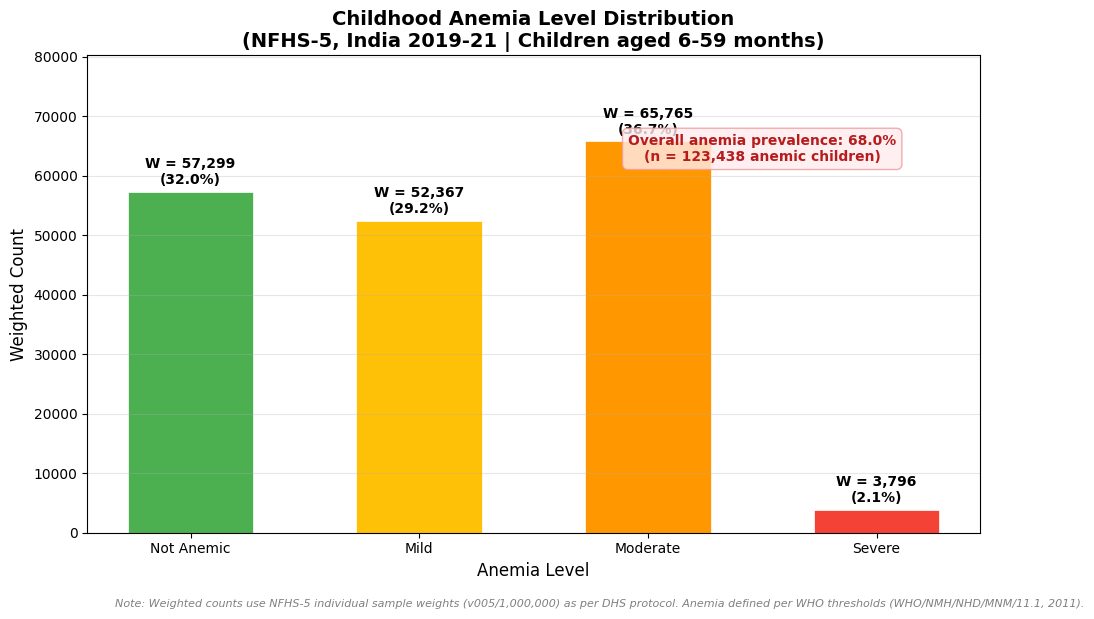

✓ Distribution figure saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs(
    '/content/stage1_results/figures',
    exist_ok=True)

# ── Weighted counts — full dataset ────────────────
w_total = df['survey_weight'].sum()

labels4 = ['Not Anemic', 'Mild',
           'Moderate', 'Severe']
colors4 = ['#4CAF50', '#FFC107',
           '#FF9800', '#F44336']

w_vals = [
    df.loc[df['anemia_level']==i,
           'survey_weight'].sum()
    for i in [0, 1, 2, 3]
]
w_pcts = [v/w_total*100 for v in w_vals]
n_vals = [int((df['anemia_level']==i).sum())
          for i in [0, 1, 2, 3]]

print("Weighted distribution (full dataset):")
for label, wv, pct, nv in zip(
        labels4, w_vals, w_pcts, n_vals):
    print(f"  {label:<12} "
          f"W={wv:>10,.0f} "
          f"({pct:.1f}%)  "
          f"n={nv:>7,}")
print(f"\n  Total        "
      f"W={w_total:>10,.0f}  "
      f"n={len(df):>7,}")
print(f"\n  Anemia prev: "
      f"{sum(w_vals[1:])/w_total*100:.1f}% "
      f"(weighted)")

# ── Figure ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels4, w_vals,
    color=colors4,
    edgecolor='white',
    linewidth=0.5,
    width=0.55)

ax.set_title(
    'Childhood Anemia Level Distribution\n'
    '(NFHS-5, India 2019-21 | '
    'Children aged 6-59 months)',
    fontsize=14, fontweight='bold')
ax.set_ylabel('Weighted Count', fontsize=12)
ax.set_xlabel('Anemia Level', fontsize=12)
ax.set_ylim(0, max(w_vals) * 1.22)
ax.grid(True, axis='y', alpha=0.3)

for bar, wv, pct, nv in zip(
        bars, w_vals, w_pcts, n_vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(w_vals)*0.012,
        f'W = {wv:,.0f}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')

# Anemia prevalence annotation
ax.annotate(
    f'Overall anemia prevalence: '
    f'{sum(w_vals[1:])/w_total*100:.1f}%\n'
    f'(n = {sum(n_vals[1:]):,} anemic children)',
    xy=(2.5, max(w_vals)*0.95),
    fontsize=10,
    color='#B71C1C',
    fontweight='bold',
    ha='center',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#FFEBEE',
        edgecolor='#EF9A9A',
        alpha=0.8)
)

fig.text(
    0.12, -0.02,
    'Note: Weighted counts use NFHS-5 '
    'individual sample weights '
    '(v005/1,000,000) as per DHS protocol. '
    'Anemia defined per WHO thresholds '
    '(WHO/NMH/NHD/MNM/11.1, 2011).',
    fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/'
    'B4_distribution_weighted_final.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Distribution figure saved")

# Download
from google.colab import files
files.download(
    '/content/stage1_results/figures/'
    'B4_distribution_weighted_final.png')
print("✓ Download started")

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs(
    '/content/stage1_results/figures',
    exist_ok=True)

# ── Weighted counts ───────────────────────────────
w_total = df['survey_weight'].sum()

# 4-class
labels4 = ['Not Anemic', 'Mild',
           'Moderate', 'Severe']
colors4 = ['#4CAF50', '#FFC107',
           '#FF9800', '#F44336']

w_vals4 = [
    df.loc[df['anemia_level']==i,
           'survey_weight'].sum()
    for i in [0, 1, 2, 3]
]
w_pcts4 = [v/w_total*100 for v in w_vals4]
n_vals4 = [
    int((df['anemia_level']==i).sum())
    for i in [0, 1, 2, 3]
]

# Binary
w_not_anemic = w_vals4[0]
w_anemic     = sum(w_vals4[1:])
n_not_anemic = n_vals4[0]
n_anemic     = sum(n_vals4[1:])

labels2 = ['Not Anemic', 'Anemic']
colors2 = ['#4CAF50', '#F44336']
w_vals2 = [w_not_anemic, w_anemic]
w_pcts2 = [v/w_total*100 for v in w_vals2]
n_vals2 = [n_not_anemic, n_anemic]

print("Weighted distribution:")
print(f"\n4-Class:")
for l, wv, pct, nv in zip(
        labels4, w_vals4, w_pcts4, n_vals4):
    print(f"  {l:<12} "
          f"W={wv:>10,.0f} ({pct:.1f}%)  "
          f"n={nv:>7,}")

print(f"\nBinary:")
for l, wv, pct, nv in zip(
        labels2, w_vals2, w_pcts2, n_vals2):
    print(f"  {l:<12} "
          f"W={wv:>10,.0f} ({pct:.1f}%)  "
          f"n={nv:>7,}")

print(f"\nAnemia prevalence (weighted): "
      f"{w_pcts2[1]:.1f}%")

Weighted distribution:

4-Class:
  Not Anemic   W=    57,299 (32.0%)  n= 60,378
  Mild         W=    52,367 (29.2%)  n= 52,695
  Moderate     W=    65,765 (36.7%)  n= 66,693
  Severe       W=     3,796 (2.1%)  n=  4,050

Binary:
  Not Anemic   W=    57,299 (32.0%)  n= 60,378
  Anemic       W=   121,928 (68.0%)  n=123,438

Anemia prevalence (weighted): 68.0%


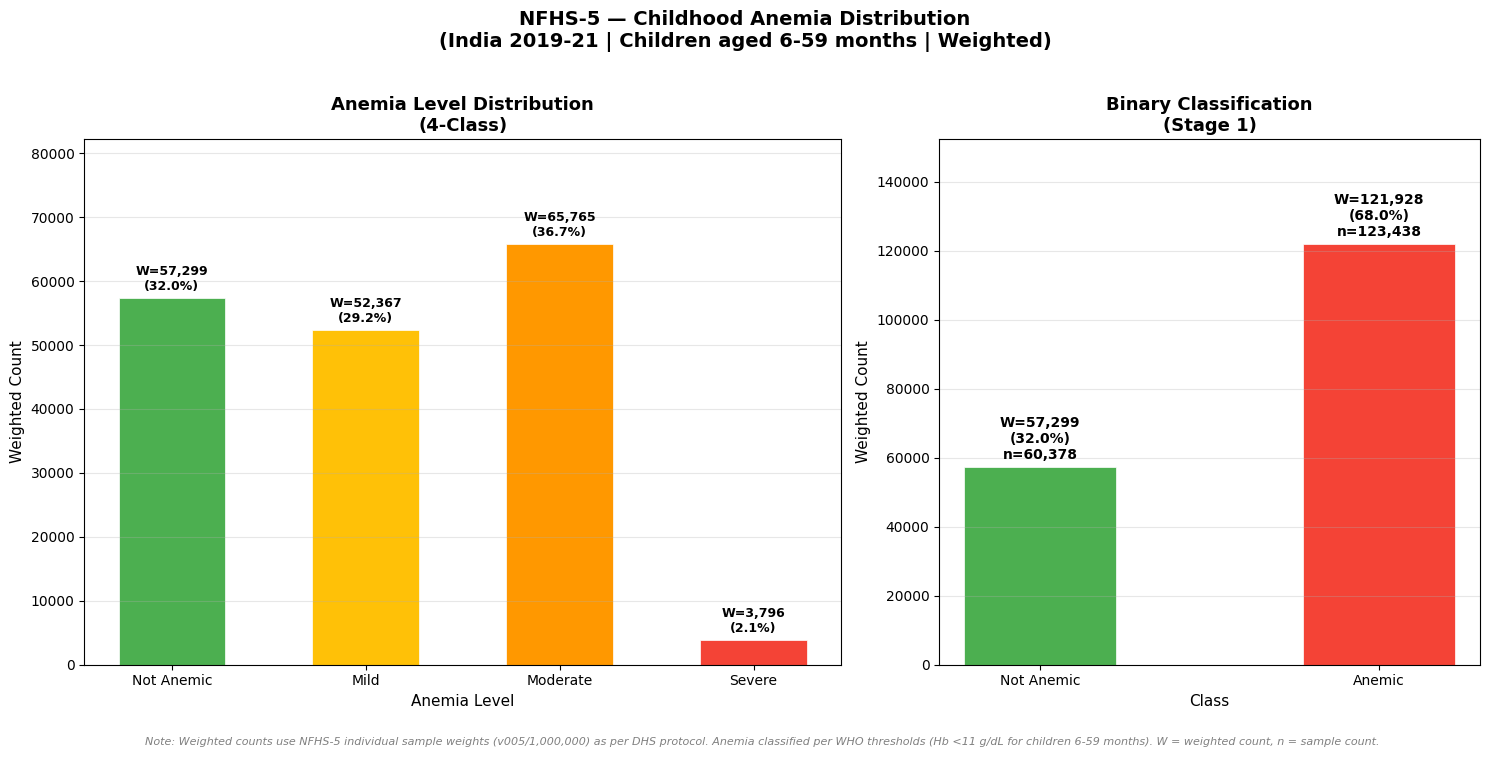

✓ Figure saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


In [ ]:
# ── Figure ────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={'width_ratios': [1.4, 1]})

# ── Left: 4-class ─────────────────────────────────
bars1 = axes[0].bar(
    labels4, w_vals4,
    color=colors4,
    edgecolor='white',
    linewidth=0.5,
    width=0.55)

axes[0].set_title(
    'Anemia Level Distribution\n'
    '(4-Class)',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel(
    'Weighted Count', fontsize=11)
axes[0].set_xlabel(
    'Anemia Level', fontsize=11)
axes[0].set_ylim(0, max(w_vals4)*1.25)
axes[0].grid(True, axis='y', alpha=0.3)

for bar, wv, pct, nv in zip(
        bars1, w_vals4, w_pcts4, n_vals4):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(w_vals4)*0.012,
        f'W={wv:,.0f}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')



# ── Right: Binary ─────────────────────────────────
bars2 = axes[1].bar(
    labels2, w_vals2,
    color=colors2,
    edgecolor='white',
    linewidth=0.5,
    width=0.45)

axes[1].set_title(
    'Binary Classification\n'
    '(Stage 1)',
    fontsize=13, fontweight='bold')
axes[1].set_ylabel(
    'Weighted Count', fontsize=11)
axes[1].set_xlabel(
    'Class', fontsize=11)
axes[1].set_ylim(0, max(w_vals2)*1.25)
axes[1].grid(True, axis='y', alpha=0.3)

for bar, wv, pct, nv in zip(
        bars2, w_vals2, w_pcts2, n_vals2):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(w_vals2)*0.012,
        f'W={wv:,.0f}\n({pct:.1f}%)\n'
        f'n={nv:,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold')



plt.suptitle(
    'NFHS-5 — Childhood Anemia Distribution\n'
    '(India 2019-21 | '
    'Children aged 6-59 months | Weighted)',
    fontsize=14, fontweight='bold', y=1.02)

fig.text(
    0.1, -0.03,
    'Note: Weighted counts use NFHS-5 '
    'individual sample weights '
    '(v005/1,000,000) as per DHS protocol. '
    'Anemia classified per WHO thresholds '
    '(Hb <11 g/dL for children 6-59 months). '
    'W = weighted count, n = sample count.',
    fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/'
    'B4_distribution_4class_binary.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure saved")

# Download
from google.colab import files
files.download(
    '/content/stage1_results/figures/'
    'B4_distribution_4class_binary.png')
print("✓ Download started")

In [ ]:
import json
import os

os.makedirs(
    '/content/stage1_results', exist_ok=True)

# Updated metrics with both unweighted
# and weighted figures
stage1_metrics_updated = {

    # ── Sample counts (unweighted) ────────────────
    # These are actual number of children
    # surveyed — report in Methods section
    'total_records'        : 183816,
    'not_anemic_count'     : 60378,
    'mild_count'           : 52695,
    'moderate_count'       : 66693,
    'severe_count'         : 4050,
    'anemic_count'         : 123438,

    # ── Unweighted percentages ────────────────────
    # Do NOT use these in paper text
    # Kept here for reference only
    'uw_not_anemic_pct'    : 32.85,
    'uw_mild_pct'          : 28.67,
    'uw_moderate_pct'      : 36.28,
    'uw_severe_pct'        : 2.20,
    'uw_anemia_prevalence' : 67.15,

    # ── Weighted percentages ──────────────────────
    # USE THESE in paper text and figures
    # Population-representative estimates
    'w_not_anemic_pct'     : 32.0,
    'w_mild_pct'           : 29.2,
    'w_moderate_pct'       : 36.7,
    'w_severe_pct'         : 2.1,
    'w_anemia_prevalence'  : 68.0,

    # ── Model performance (Stage 1) ───────────────
    # These do not change with weighting
    'best_model'           : 'LightGBM',
    'threshold'            : 0.60,
    'accuracy'             : 0.6544,
    'precision_macro'      : 0.6200,
    'recall_macro'         : 0.6300,
    'f1_macro'             : 0.6245,
    'f1_weighted'          : 0.6600,
    'f1_anemic'            : 0.7306,
    'f1_not_anemic'        : 0.5184,
    'auc_roc'              : 0.6838,
    'cohen_kappa'          : 0.2519,

    # ── SHAP top 5 ────────────────────────────────
    'shap_rank1'           : 'child_age_months',
    'shap_rank1_value'     : 0.5551,
    'shap_rank2'           : 'mother_anemia',
    'shap_rank2_value'     : 0.2931,
    'shap_rank3'           : 'state',
    'shap_rank3_value'     : 0.1721,
    'shap_rank4'           : 'living_children',
    'shap_rank4_value'     : 0.1406,
    'shap_rank5'           : 'birth_interval',
    'shap_rank5_value'     : 0.1304,

    # ── Dataset info ──────────────────────────────
    'dataset'              : 'NFHS-5 KR file',
    'survey_period'        : '2019-21',
    'country'              : 'India',
    'age_group'            : '6-59 months',
    'weight_variable'      : 'v005/1000000',
    'anemia_variable'      : 'hw57',
    'who_threshold'        : (
        'Hb <11 g/dL for children 6-59 months'),
}

# Save
with open(
        '/content/stage1_results/'
        'stage1_metrics_final.json', 'w') as f:
    json.dump(
        stage1_metrics_updated, f, indent=2)

print("✓ Updated metrics JSON saved")
print("\nKey figures for paper:")
print(f"  Total records    : "
      f"{stage1_metrics_updated['total_records']:,}")
print(f"  Anemia prev (W)  : "
      f"{stage1_metrics_updated['w_anemia_prevalence']}%")
print(f"  Not anemic (W)   : "
      f"{stage1_metrics_updated['w_not_anemic_pct']}%")
print(f"  Mild (W)         : "
      f"{stage1_metrics_updated['w_mild_pct']}%")
print(f"  Moderate (W)     : "
      f"{stage1_metrics_updated['w_moderate_pct']}%")
print(f"  Severe (W)       : "
      f"{stage1_metrics_updated['w_severe_pct']}%")
print(f"\n  Best model       : "
      f"{stage1_metrics_updated['best_model']}")
print(f"  Threshold        : "
      f"{stage1_metrics_updated['threshold']}")
print(f"  AUC-ROC          : "
      f"{stage1_metrics_updated['auc_roc']}")
print(f"  F1 Macro         : "
      f"{stage1_metrics_updated['f1_macro']}")
print(f"  Cohen Kappa      : "
      f"{stage1_metrics_updated['cohen_kappa']}")

# Download
from google.colab import files
files.download(
    '/content/stage1_results/'
    'stage1_metrics_final.json')
print("\n✓ Download started")

✓ Updated metrics JSON saved

Key figures for paper:
  Total records    : 183,816
  Anemia prev (W)  : 68.0%
  Not anemic (W)   : 32.0%
  Mild (W)         : 29.2%
  Moderate (W)     : 36.7%
  Severe (W)       : 2.1%

  Best model       : LightGBM
  Threshold        : 0.6
  AUC-ROC          : 0.6838
  F1 Macro         : 0.6245
  Cohen Kappa      : 0.2519


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download started


In [ ]:
print(f"Actual total records: {len(df):,}")
print(f"Anemia level counts:")
print(df['anemia_level'].value_counts()
        .sort_index())
print(f"\nSum of counts: "
      f"{df['anemia_level'].value_counts().sum():,}")

Actual total records: 183,816
Anemia level counts:
anemia_level
0    60378
1    52695
2    66693
3     4050
Name: count, dtype: int64

Sum of counts: 183,816
